In [2]:
from google.colab import files
uploaded = files.upload()  # This will open a dialog to choose your CSV file


KeyboardInterrupt: 

In [ ]:
import os
print(os.getcwd())  # shows current working directory
print(os.listdir()) # lists files in the current folder


/content
['.config', 'clean_token_chunks.cleaned.csv', 'sample_data']


Selected 400 words (top 200 frequent + 200 random from remainder).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Got embeddings for 400 words.

Cosine Similarity Matrix (top 10 rows):
            the       and      that     which       for       are      with  \
the    1.000000  0.998104  0.995607  0.994815  0.997263  0.996841  0.998289   
and    0.998104  1.000000  0.995567  0.995316  0.998237  0.998641  0.998760   
that   0.995607  0.995567  1.000000  0.999399  0.992303  0.992820  0.993906   
which  0.994815  0.995316  0.999399  1.000000  0.991114  0.992033  0.992784   
for    0.997263  0.998237  0.992303  0.991114  1.000000  0.998660  0.999109   
are    0.996841  0.998641  0.992820  0.992033  0.998660  1.000000  0.998725   
with   0.998289  0.998760  0.993906  0.992784  0.999109  0.998725  1.000000   
not    0.995050  0.997799  0.995491  0.995525  0.995804  0.996116  0.995521   
but    0.997594  0.998963  0.997722  0.997211  0.997018  0.997453  0.997932   
this   0.995627  0.996245  0.997186  0.996421  0.995379  0.995185  0.995168   

            not       but      this  ...  geometricae  diff

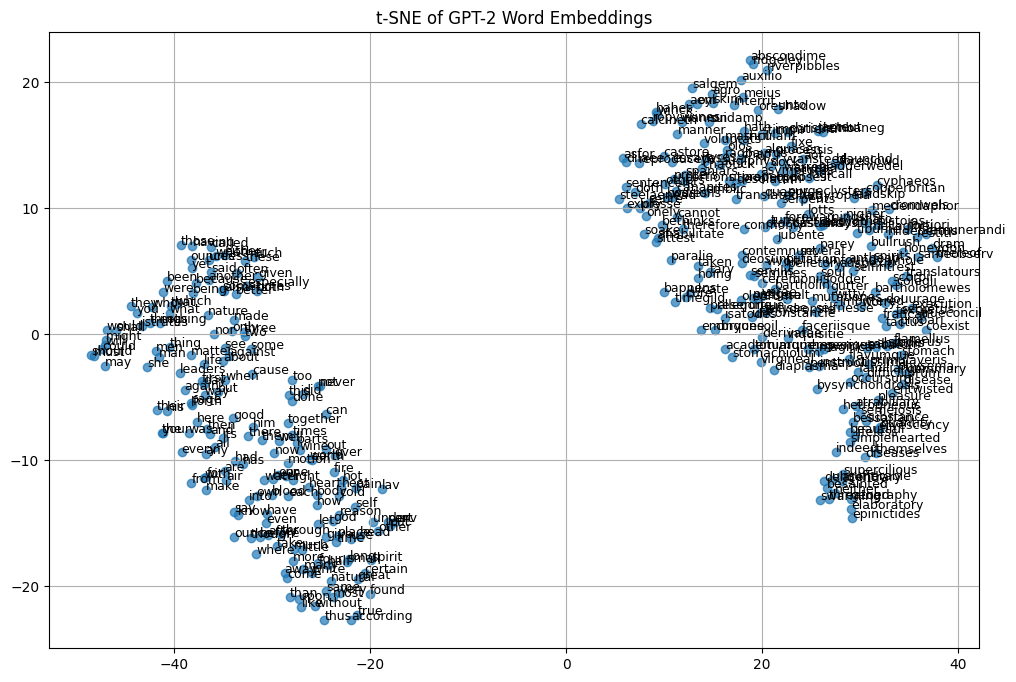


Cluster Assignments:
the: Cluster 0
and: Cluster 0
that: Cluster 0
which: Cluster 0
for: Cluster 0
are: Cluster 0
with: Cluster 0
not: Cluster 0
but: Cluster 0
this: Cluster 0
they: Cluster 0
from: Cluster 0
all: Cluster 0
his: Cluster 0
have: Cluster 0
them: Cluster 0
their: Cluster 0
may: Cluster 0
one: Cluster 0
was: Cluster 0
there: Cluster 0
more: Cluster 0
into: Cluster 0
then: Cluster 0
other: Cluster 0
being: Cluster 0
some: Cluster 0
will: Cluster 0
also: Cluster 0
page: Cluster 0
when: Cluster 0
its: Cluster 0
any: Cluster 0
you: Cluster 0
these: Cluster 0
things: Cluster 0
those: Cluster 0
upon: Cluster 0
must: Cluster 0
such: Cluster 0
because: Cluster 0
first: Cluster 0
out: Cluster 0
made: Cluster 0
yet: Cluster 0
very: Cluster 0
were: Cluster 0
much: Cluster 0
same: Cluster 0
body: Cluster 0
part: Cluster 0
great: Cluster 0
water: Cluster 0
most: Cluster 0
what: Cluster 0
hath: Cluster 1
therefore: Cluster 3
our: Cluster 0
him: Cluster 0
two: Cluster 0
parts: Cluster 0


In [ ]:
# 2. Imports
import pandas as pd
import numpy as np
import torch
import re
import random
import matplotlib.pyplot as plt
from collections import Counter
from transformers import GPT2Tokenizer, GPT2Model
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# 3. Load Your Dataset
df = pd.read_csv("clean_token_chunks.cleaned.csv")
text_data = df["Chunk_clean"].astype(str)
full_text = " ".join(text_data)

# 4. Extract and Select Words (400 total: 200 most frequent + 200 random others)
tokens = re.findall(r'\b[a-z]{3,}\b', full_text.lower())  # alphabetic words, length >= 3
# optional length filter to avoid very long tokens / OCR artifacts
tokens = [w for w in tokens if len(w) <= 15]

word_counts = Counter(tokens)
all_unique = list(word_counts.keys())

# Most frequent
TOP_N = 200
top_words = [w for w, _ in word_counts.most_common(TOP_N)]

# Random from the remainder (reproducible)
remaining_words = list(set(all_unique) - set(top_words))
random.seed(42)
np.random.seed(42)
RANDOM_N = min(200, len(remaining_words))
random_words = random.sample(remaining_words, RANDOM_N) if RANDOM_N > 0 else []

# Combine (if there are fewer than 400 unique words available, we take as many as we can)
words = top_words + random_words

print(f"Selected {len(words)} words "
      f"(top {len(top_words)} frequent + {len(random_words)} random from remainder).")

# 5. Load GPT-2
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2")

# 6. Generate Embeddings
def get_embedding(word):
    tokens = tokenizer(word, return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = model(**tokens)
    return outputs.last_hidden_state[0, -1]  # Last token's hidden state

embeddings = []
valid_words = []

for word in words:
    try:
        vec = get_embedding(word).numpy()
        embeddings.append(vec)
        valid_words.append(word)
    except Exception as e:
        print(f"Skipped '{word}': {e}")

print(f"Got embeddings for {len(valid_words)} words.")

# 7. Cosine Similarity Matrix
sim_matrix = cosine_similarity(embeddings)
sim_df = pd.DataFrame(sim_matrix, index=valid_words, columns=valid_words)

print("\nCosine Similarity Matrix (top 10 rows):")
print(sim_df.head(10))

# 8. Save Similarity Matrix to CSV
sim_df.to_csv("word_similarity_matrix.csv")
print("\nSaved similarity matrix as 'word_similarity_matrix.csv'")

# Convert to NumPy array before using t-SNE
embeddings = np.array(embeddings)

# 9. t-SNE Visualization
# Ensure perplexity is valid: must be < number of samples
perplexity = min(20, max(5, len(valid_words) // 4))  # simple heuristic
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
reduced = tsne.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.7)
for i, word in enumerate(valid_words):
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]), fontsize=9)
plt.title("t-SNE of GPT-2 Word Embeddings")
plt.grid(True)
plt.show()

# 10. K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)

print("\nCluster Assignments:")
for word, label in zip(valid_words, labels):
    print(f"{word}: Cluster {label}")


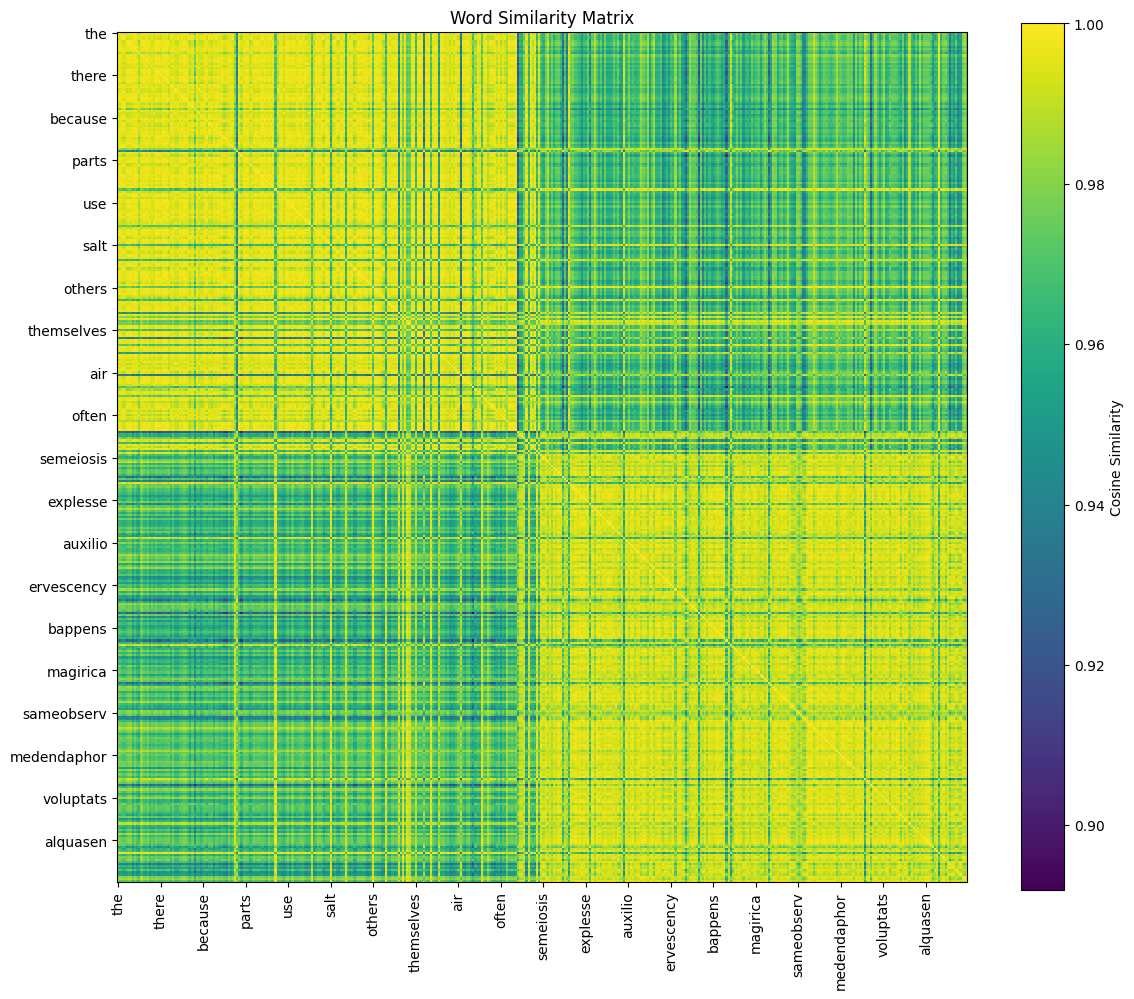

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert the similarity matrix to a NumPy array
matrix = sim_df.values
words = sim_df.index.tolist()

plt.figure(figsize=(12, 10))
im = plt.imshow(matrix, cmap="viridis", interpolation="nearest")

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label("Cosine Similarity")

# Tick labels (show fewer for readability)
step = max(1, len(words) // 20)  # show about 20 labels
plt.xticks(np.arange(0, len(words), step), [words[i] for i in range(0, len(words), step)], rotation=90)
plt.yticks(np.arange(0, len(words), step), [words[i] for i in range(0, len(words), step)])

plt.title("Word Similarity Matrix")
plt.tight_layout()
plt.show()


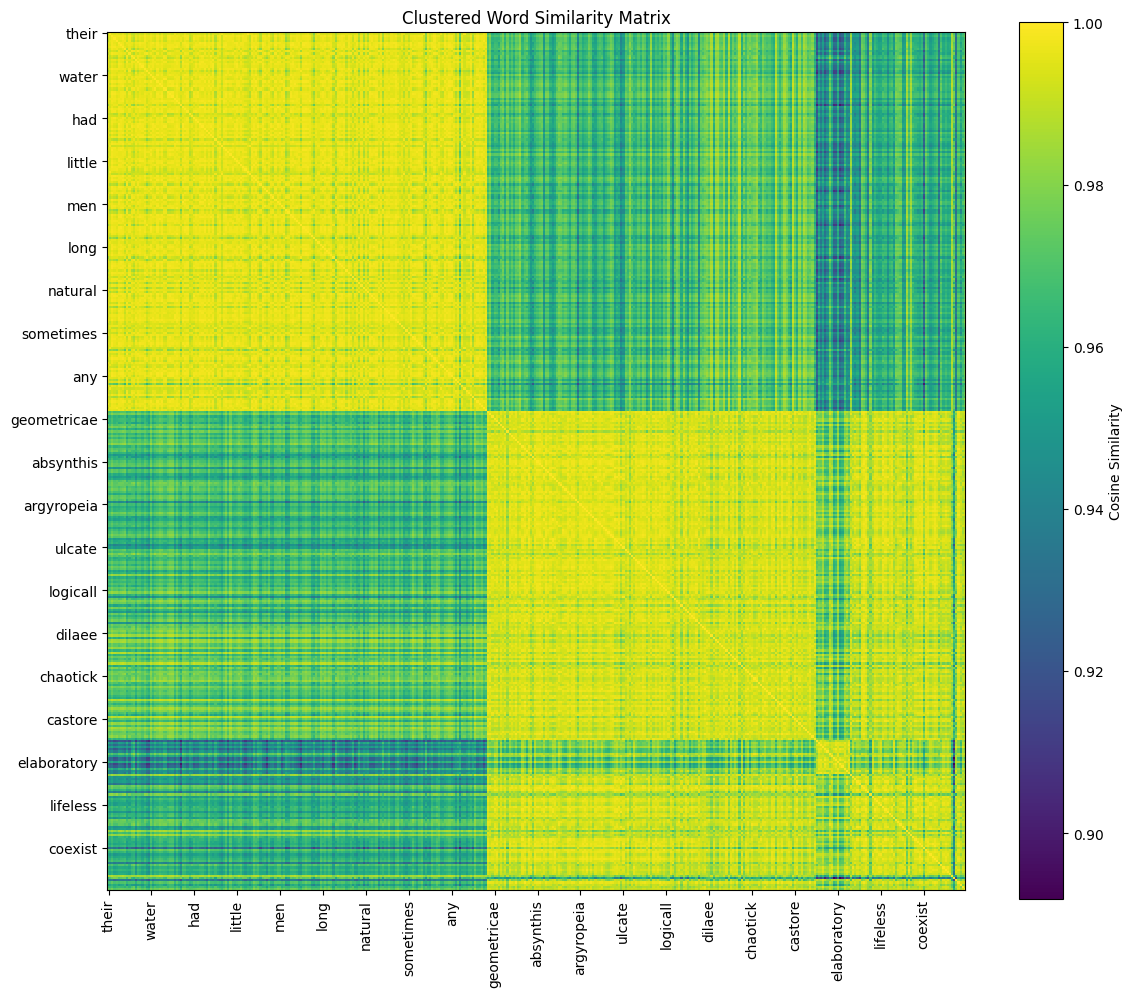

In [ ]:
# Sort rows/cols by cluster labels
order = np.argsort(labels)
sorted_words = [valid_words[i] for i in order]
sorted_matrix = sim_df.loc[sorted_words, sorted_words].values

plt.figure(figsize=(12, 10))
im = plt.imshow(sorted_matrix, cmap="viridis", interpolation="nearest")

plt.colorbar(label="Cosine Similarity")
step = max(1, len(sorted_words) // 20)
plt.xticks(np.arange(0, len(sorted_words), step), [sorted_words[i] for i in range(0, len(sorted_words), step)], rotation=90)
plt.yticks(np.arange(0, len(sorted_words), step), [sorted_words[i] for i in range(0, len(sorted_words), step)])

plt.title("Clustered Word Similarity Matrix")
plt.tight_layout()
plt.show()


In [ ]:
!pip install gensim


In [ ]:
!pip install gensim umap-learn


In [ ]:
from gensim.models import Word2Vec


In [ ]:
!pip install -U --quiet "numpy==1.26.4" "scipy==1.11.4" "gensim==4.3.2"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 9.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 10.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.1 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.11.4 which is incompatible.


In [ ]:
import os, signal
os.kill(os.getpid(), 9)


In [ ]:
from gensim.models import Word2Vec
import numpy as np, scipy
print("OK:", np.__version__)


OK: 1.26.4


In [ ]:
from gensim.models import Word2Vec

sentences = [["this","is","a","test"], ["another","short","test"], ["word2vec","works"]]
model = Word2Vec(sentences, vector_size=50, window=3, min_count=1, workers=2, sg=1, epochs=5)
print(model.wv.most_similar("test"))


[('this', 0.13204392790794373), ('word2vec', 0.1267007291316986), ('works', 0.042373016476631165), ('a', 0.012442179024219513), ('short', -0.01447527389973402), ('is', -0.05974648892879486), ('another', -0.11821284145116806)]


Using inferred text column: Chunk_clean
Selected 400 words from the trained vocabulary.
Saved similarity matrix to 'word_similarity_matrix_word2vec.csv'
Saved clusters to 'word_clusters_word2vec.csv'
Saved nearest neighbors to 'word2vec_neighbors.csv'
Saved t-SNE coordinates to 'word2vec_tsne.csv'


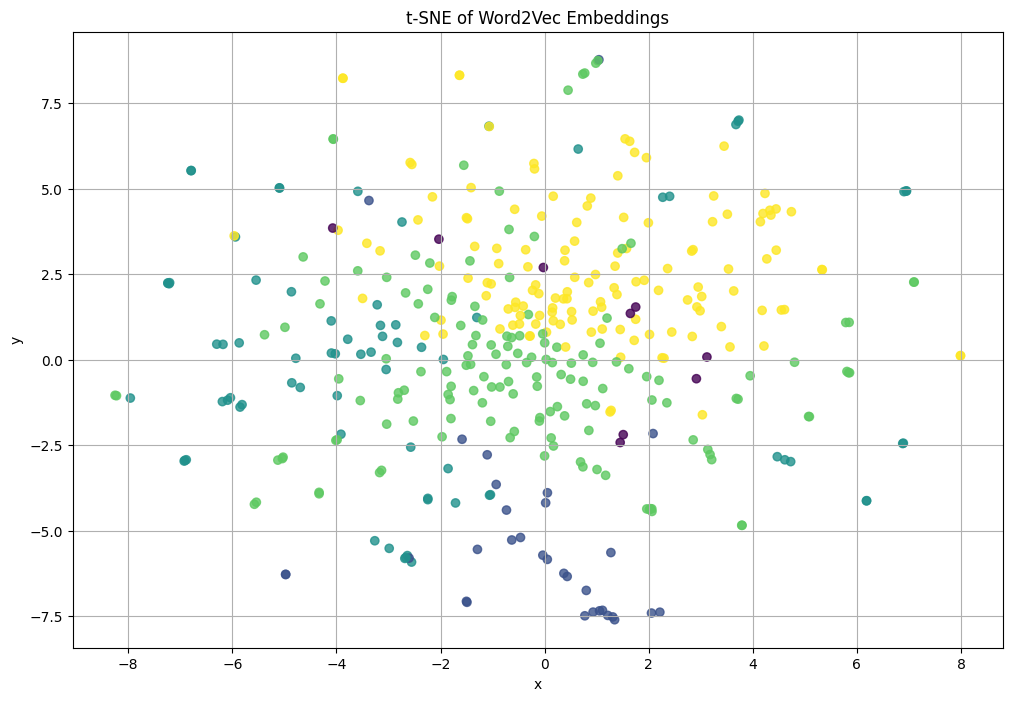

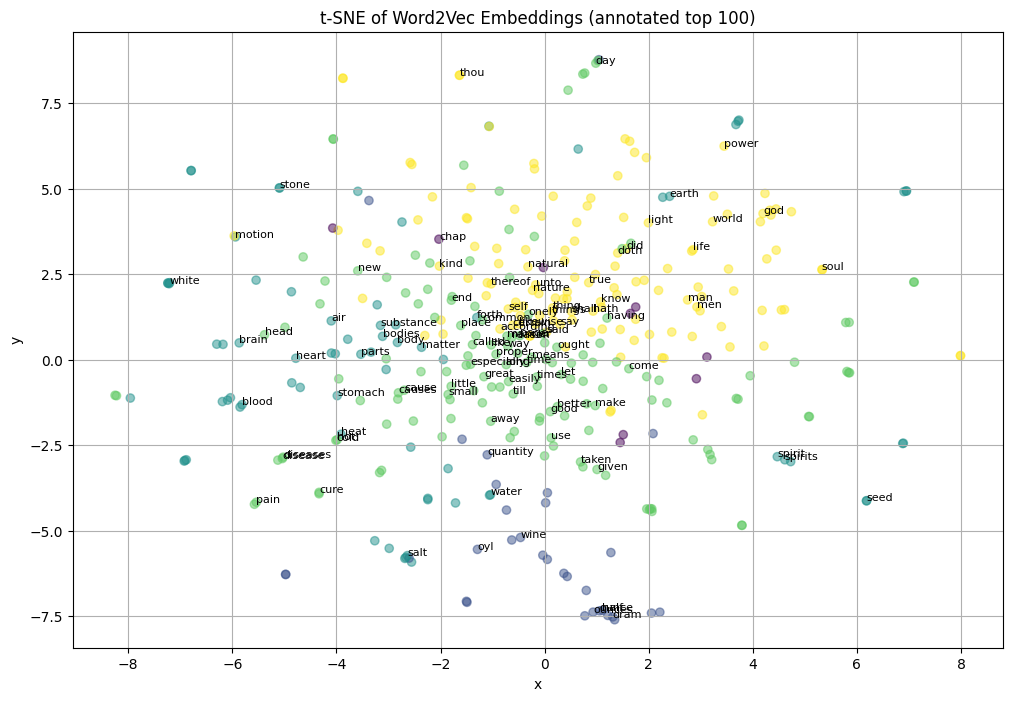

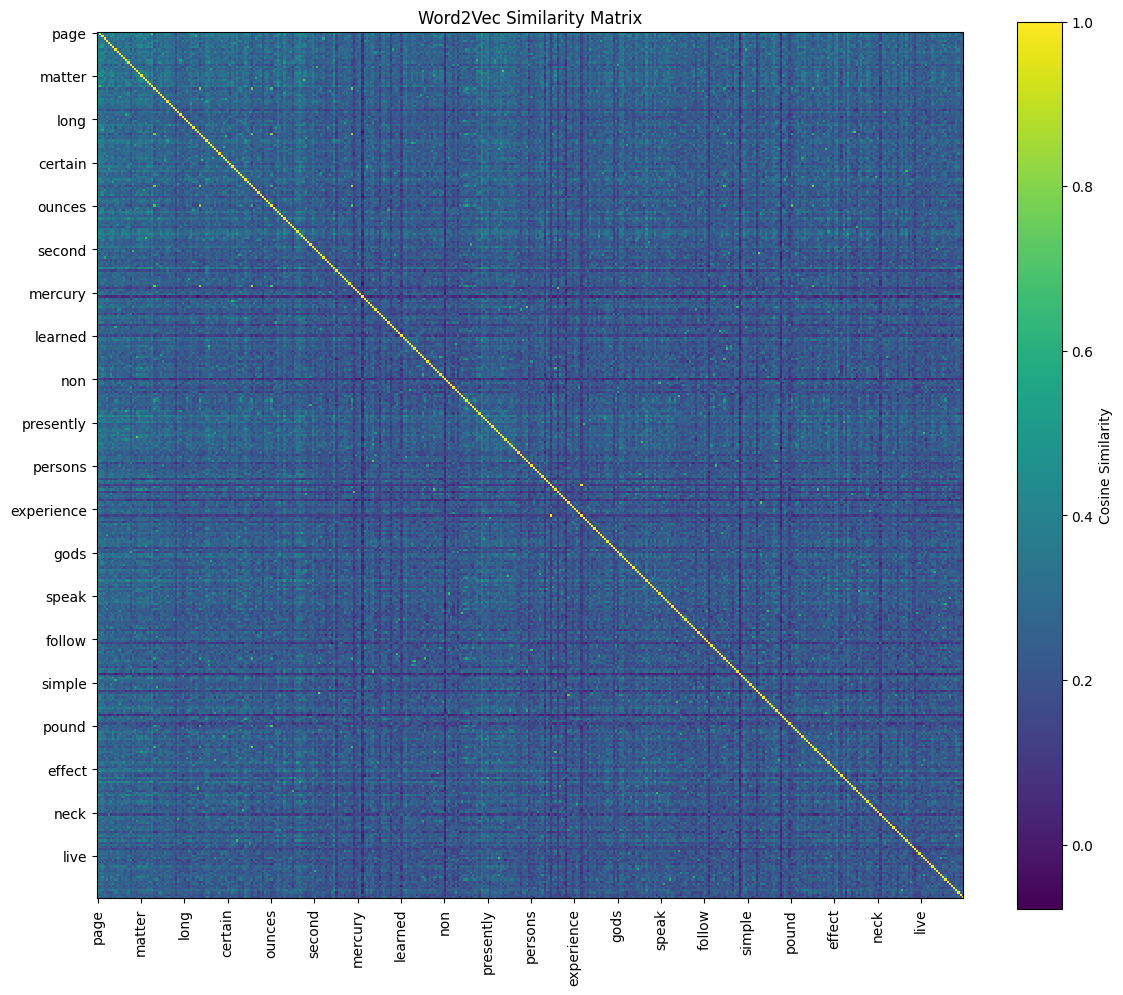

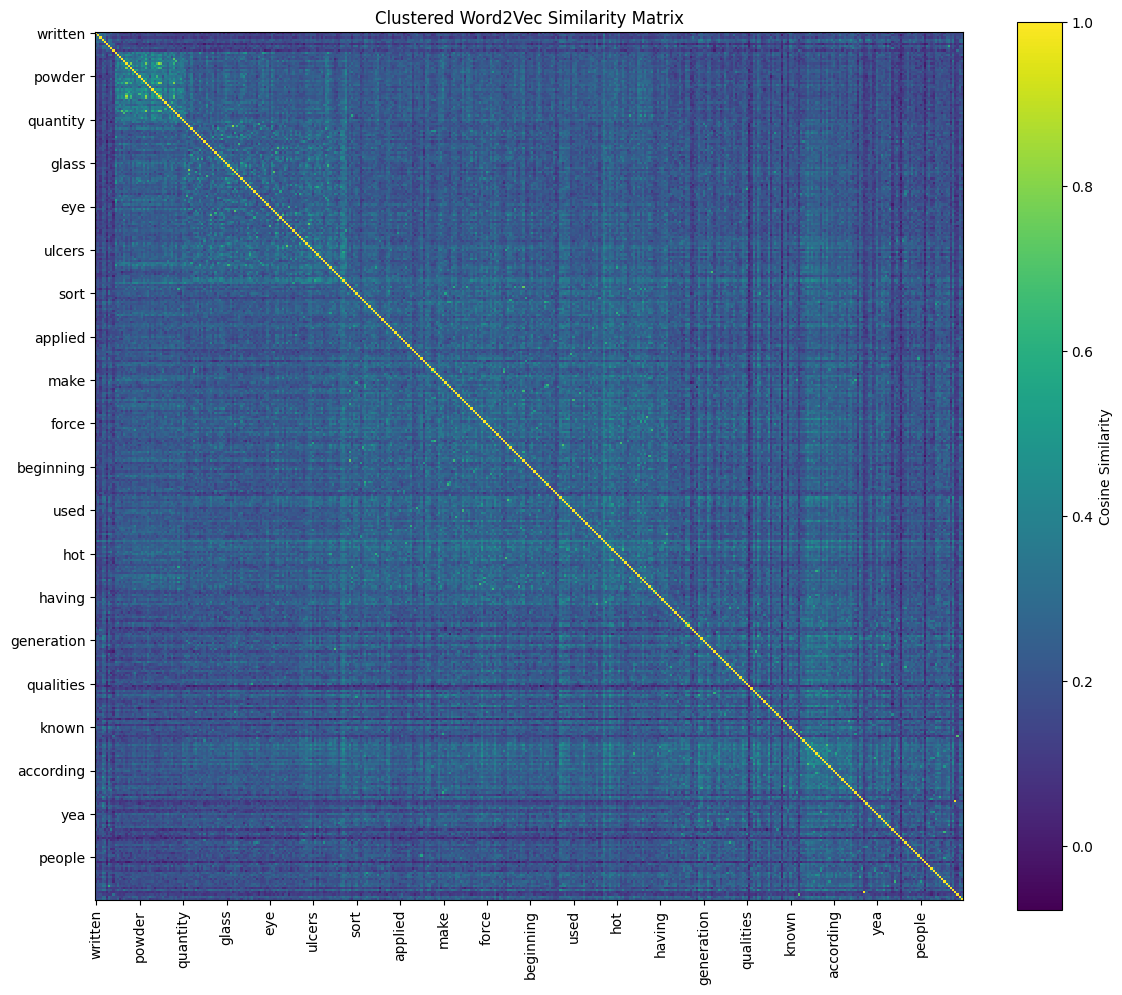

Done. Artifacts saved:
  word2vec.model, word2vec.txt
  word_similarity_matrix_word2vec.csv
  word_clusters_word2vec.csv
  word2vec_neighbors.csv
  word2vec_tsne.csv
  heatmap_word2vec.png, heatmap_word2vec_clustered.png


In [ ]:
# ===========================
# 1) Setup (Colab-friendly)
# ===========================
# If running in Colab, uncomment the next two lines to install dependencies:
# !pip -q install gensim umap-learn

import os
import re
import glob
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

# Reproducibility
random.seed(42)
np.random.seed(42)

# ===========================
# 2) Config
# ===========================
FILENAME = "clean_token_chunks.cleaned.csv"  # change if needed
USE_GOOGLE_DRIVE = False                    # set True if the file is on Drive and you want to search it
TOP_K_WORDS = 400                           # how many words to visualize / matrix size
SAVE_NEIGHBORS_TOPK = 10                    # nearest neighbors to export per word

# Word2Vec hyperparameters (tune as needed)
W2V_PARAMS = dict(
    vector_size=300,  # embedding dimension
    window=5,         # context window
    min_count=3,      # ignore words with total freq < 3
    workers=4,        # use your CPU cores
    sg=1,             # 1 = skip-gram, 0 = CBOW
    negative=10,
    epochs=10
)

# ===========================
# 3) Resolve CSV path
# ===========================
def resolve_csv_path(filename=FILENAME, use_drive=USE_GOOGLE_DRIVE):
    if os.path.exists(filename):
        return filename
    if use_drive:
        # In Colab, mount drive first:
        # from google.colab import drive
        # drive.mount('/content/drive')
        drive_root = "/content/drive"
        if os.path.exists(drive_root):
            matches = glob.glob(os.path.join(drive_root, "**", filename), recursive=True)
            if matches:
                return matches[0]
    raise FileNotFoundError(
        f"Could not find {filename}. Place it in the working directory or set USE_GOOGLE_DRIVE=True after mounting."
    )

csv_path = resolve_csv_path()

# ===========================
# 4) Load data and pick text column
# ===========================
df = pd.read_csv(csv_path)

if "chunk_text" in df.columns:
    text_data = df["Chunk_clean"].astype(str)
else:
    # Pick the column with the largest average string length
    candidate = max(df.columns, key=lambda c: df[c].astype(str).str.len().mean())
    print(f"Using inferred text column: {candidate}")
    text_series = df[candidate].astype(str)

# ===========================
# 5) Tokenization
# ===========================
# Simple tokenizer: lowercase, keep only [a-z], length >= 3, remove stopwords.
# You can replace with spaCy or a domain-specific tokenizer if needed.
STOP = set(ENGLISH_STOP_WORDS)

def tokenize_line(text: str):
    # keep ASCII letters only; lower; filter by length >= 3
    tokens = re.findall(r"[a-z]+", text.lower())
    tokens = [t for t in tokens if len(t) >= 3 and t not in STOP]
    return tokens

class SentenceIterator:
    def __init__(self, series):
        self.series = series
    def __iter__(self):
        for line in self.series:
            toks = tokenize_line(line)
            if toks:
                yield toks

sentences = SentenceIterator(text_series)

# ===========================
# 6) Train Word2Vec
# ===========================
w2v = Word2Vec(**W2V_PARAMS)
w2v.build_vocab(sentences)
w2v.train(sentences, total_examples=w2v.corpus_count, epochs=w2v.epochs)

# Save model and vectors for reuse
w2v.save("word2vec.model")
w2v.wv.save_word2vec_format("word2vec.txt")  # text format (word + vector per line)

# ===========================
# 7) Select words to visualize
# ===========================
# Get vocabulary and counts
vocab_words = list(w2v.wv.key_to_index.keys())

# Rank words by their training count (most frequent first)
def word_count(w):
    try:
        return w2v.wv.get_vecattr(w, "count")
    except Exception:
        return 0

vocab_words.sort(key=lambda w: word_count(w), reverse=True)

# Take the top-K frequent words
selected_words = vocab_words[: min(TOP_K_WORDS, len(vocab_words))]
print(f"Selected {len(selected_words)} words from the trained vocabulary.")

# ===========================
# 8) Build embeddings matrix
# ===========================
embeddings = np.vstack([w2v.wv[w] for w in selected_words])

# Optionally L2 normalize before clustering/similarity (cosine is scale-invariant, but KMeans may benefit)
# from sklearn.preprocessing import normalize
# embeddings = normalize(embeddings)

# ===========================
# 9) Cosine similarity matrix
# ===========================
sim_matrix = cosine_similarity(embeddings)
sim_df = pd.DataFrame(sim_matrix, index=selected_words, columns=selected_words)
sim_df.to_csv("word_similarity_matrix_word2vec.csv")
print("Saved similarity matrix to 'word_similarity_matrix_word2vec.csv'")

# ===========================
# 10) K-Means clustering
# ===========================
K = 5  # number of clusters (tune as needed)
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)

clusters_df = pd.DataFrame({
    "word": selected_words,
    "cluster": labels,
    "count": [word_count(w) for w in selected_words]
})
clusters_df.to_csv("word_clusters_word2vec.csv", index=False)
print("Saved clusters to 'word_clusters_word2vec.csv'")

# ===========================
# 11) Nearest neighbors per word
# ===========================
rows = []
topk = SAVE_NEIGHBORS_TOPK
for w in selected_words:
    # most_similar excludes the word itself
    sims = w2v.wv.most_similar(w, topn=topk)
    for nbr, score in sims:
        rows.append((w, nbr, float(score)))
nn_df = pd.DataFrame(rows, columns=["word", "neighbor", "similarity"])
nn_df.to_csv("word2vec_neighbors.csv", index=False)
print("Saved nearest neighbors to 'word2vec_neighbors.csv'")

# ===========================
# 12) t-SNE visualization (2D)
# ===========================
perplexity = min(30, max(5, len(selected_words)//4))
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init="pca")
reduced = tsne.fit_transform(embeddings)

tsne_df = pd.DataFrame({
    "word": selected_words,
    "x": reduced[:, 0],
    "y": reduced[:, 1],
    "cluster": labels
})
tsne_df.to_csv("word2vec_tsne.csv", index=False)
print("Saved t-SNE coordinates to 'word2vec_tsne.csv'")

# Scatter, colored by cluster (labels text can clutter for large K)
plt.figure(figsize=(12, 8))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, alpha=0.8)
plt.title("t-SNE of Word2Vec Embeddings")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

# Optional: annotate a subset to reduce clutter (e.g., 100 most frequent)
ANNOTATE_N = min(100, len(selected_words))
plt.figure(figsize=(12, 8))
plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, alpha=0.5)
for i in range(ANNOTATE_N):
    plt.annotate(selected_words[i], (reduced[i, 0], reduced[i, 1]), fontsize=8)
plt.title(f"t-SNE of Word2Vec Embeddings (annotated top {ANNOTATE_N})")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

# ===========================
# 13) Heatmaps (plain and clustered)
# ===========================
def plot_heatmap(matrix, labels_words, title, filename):
    plt.figure(figsize=(12, 10))
    im = plt.imshow(matrix, cmap="viridis", interpolation="nearest")
    cbar = plt.colorbar(im)
    cbar.set_label("Cosine Similarity")
    step = max(1, len(labels_words) // 20)
    ticks = list(range(0, len(labels_words), step))
    plt.xticks(ticks, [labels_words[i] for i in ticks], rotation=90)
    plt.yticks(ticks, [labels_words[i] for i in ticks])
    plt.title(title)
    plt.tight_layout()
    plt.show()
    # save a full-resolution image too
    plt.imsave(filename, matrix, cmap="viridis")

# Plain (original order = selected_words)
plot_heatmap(sim_matrix, selected_words, "Word2Vec Similarity Matrix", "heatmap_word2vec.png")

# Clustered (reorder by KMeans labels, and then by x position for compactness)
order = np.argsort(labels)
sorted_words = [selected_words[i] for i in order]
sorted_matrix = sim_df.loc[sorted_words, sorted_words].values
plot_heatmap(sorted_matrix, sorted_words, "Clustered Word2Vec Similarity Matrix", "heatmap_word2vec_clustered.png")

print("Done. Artifacts saved:")
print("  word2vec.model, word2vec.txt")
print("  word_similarity_matrix_word2vec.csv")
print("  word_clusters_word2vec.csv")
print("  word2vec_neighbors.csv")
print("  word2vec_tsne.csv")
print("  heatmap_word2vec.png, heatmap_word2vec_clustered.png")


In [ ]:
import numpy as np
import pandas as pd
from google.colab import files


# embeddings: np.ndarray shape [N, D]
# valid_words: list[str] length N
# OPTIONAL: labels (cluster ids), word_counts (dict word->freq)

N = len(valid_words)
assert isinstance(embeddings, np.ndarray), "embeddings must be a NumPy array"
assert embeddings.shape[0] == N, f"rows in embeddings ({embeddings.shape[0]}) != len(valid_words) ({N})"

# --- Choose metadata columns ---
meta_cols = {"word": valid_words}

# For cluster labels:
try:
    if len(labels) == N:
        meta_cols["cluster"] = list(map(int, labels))
except NameError:
    pass

# If word_counts from earlier:
try:
    meta_cols["freq"] = [int(word_counts.get(w, 0)) for w in valid_words]
except NameError:
    pass

metadata_df = pd.DataFrame(meta_cols)

# --- Write vectors.tsv (no header) ---
with open("vectors.tsv", "w", encoding="utf-8", newline="") as f:
    for row in embeddings:
        f.write("\t".join(f"{x:.6f}" for x in row) + "\n")

# --- Write metadata.tsv
# If only one column, NO header. If multiple columns, WITH header.
if metadata_df.shape[1] == 1:
    # single column: no header row
    metadata_df.to_csv("metadata.tsv", sep="\t", index=False, header=False, line_terminator="\n")
else:
    # multi-column: include header row
    metadata_df.to_csv("metadata.tsv", sep="\t", index=False, header=True, line_terminator="\n")

# --- Sanity checks (print counts exactly as Projector sees them) ---
with open("vectors.tsv", "r", encoding="utf-8") as f:
    vec_lines = sum(1 for _ in f)

with open("metadata.tsv", "r", encoding="utf-8") as f:
    meta_lines = sum(1 for _ in f)

print(f"vectors.tsv lines:   {vec_lines}")
print(f"metadata.tsv lines:  {meta_lines}  (includes header if present)")
if metadata_df.shape[1] == 1:
    assert meta_lines == vec_lines, "For single-column metadata, lines must equal number of vectors."
else:
    assert meta_lines == vec_lines + 1, "For multi-column metadata, metadata must have exactly one extra header line."

# --- Download (Colab)
files.download("vectors.tsv")
files.download("metadata.tsv")


NameError: name 'valid_words' is not defined

In [ ]:
import pandas as pd

# Supposons que selected_words contient mes 400 mots
# et embeddings mes vecteurs Word2Vec

# Vectors.tsv
import numpy as np
np.savetxt("vectors.tsv", embeddings, delimiter="\t")

# Metadata.tsv — ici juste les mots (1 colonne)
meta = pd.DataFrame({"word": selected_words})
meta.to_csv("metadata.tsv", sep="\t", index=False, header=False)  # sans header si une seule colonne

# Vérification
print("Vectors:", sum(1 for _ in open("vectors.tsv")))
print("Metadata:", sum(1 for _ in open("metadata.tsv")))


Vectors: 400
Metadata: 400


In [ ]:
meta = pd.DataFrame({
    "word": selected_words,
    "cluster": labels
})
meta.to_csv("metadata.tsv", sep="\t", index=False, header=True)


In [ ]:
# Download from Colab
files.download("vectors.tsv")
files.download("metadata.tsv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorboard.plugins import projector

# 1) Setup log directory
LOG_DIR = "projector_logs"
if os.path.exists(LOG_DIR):
    shutil.rmtree(LOG_DIR)
os.makedirs(LOG_DIR, exist_ok=True)

# Assume you already have:
# embeddings -> NumPy array shape (N, D)
# selected_words -> list length N
# Optionally: labels -> list length N

# 2) Save metadata.tsv
meta = {"word": selected_words}
if "labels" in globals() and len(labels) == len(selected_words):
    meta["cluster"] = list(map(int, labels))
pd.DataFrame(meta).to_csv(os.path.join(LOG_DIR, "metadata.tsv"),
                          sep="\t", index=False, header=True)

# 3) Create TF variable
embedding_var = tf.Variable(np.array(embeddings, dtype=np.float32), name="word_embeddings")

# 4) Create summary writer and checkpoint


count    400.000000
mean       4.234028
std        0.711067
min        2.149192
25%        3.843054
50%        4.200004
75%        4.555221
max        8.773191
dtype: float64
Mean cos (within): 0.25726312
Mean cos (across): 0.21774872


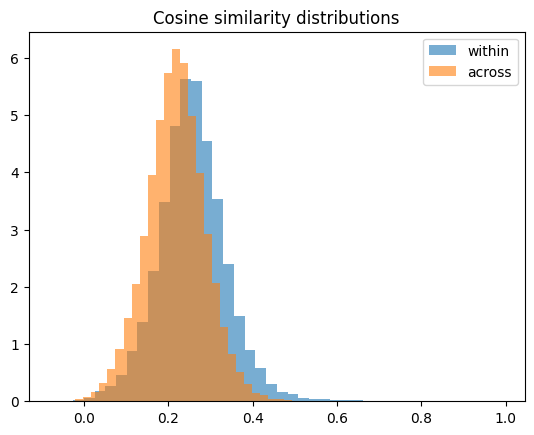

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# vector norms
norms = np.linalg.norm(embeddings, axis=1)
print(pd.Series(norms).describe())

# cosine similarities (sample pairs for speed)
from sklearn.metrics.pairwise import cosine_similarity
S = cosine_similarity(embeddings)
np.fill_diagonal(S, np.nan)

# within vs across cluster
within, across = [], []
for i in range(len(S)):
    for j in range(i+1, len(S)):
        (within if labels[i]==labels[j] else across).append(S[i,j])

print("Mean cos (within):", np.nanmean(within))
print("Mean cos (across):", np.nanmean(across))

plt.hist(within, bins=40, alpha=.6, density=True, label="within")
plt.hist(across, bins=40, alpha=.6, density=True, label="across")
plt.legend(); plt.title("Cosine similarity distributions"); plt.show()


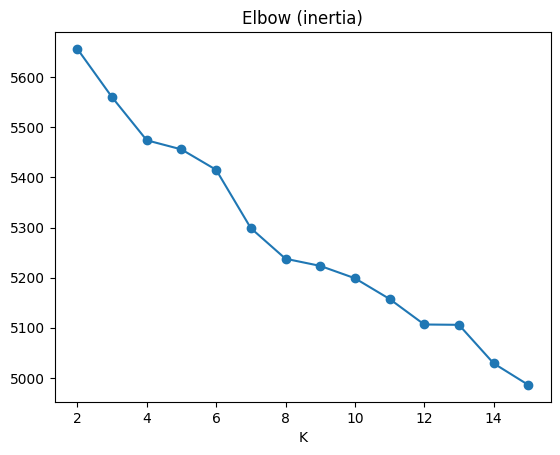

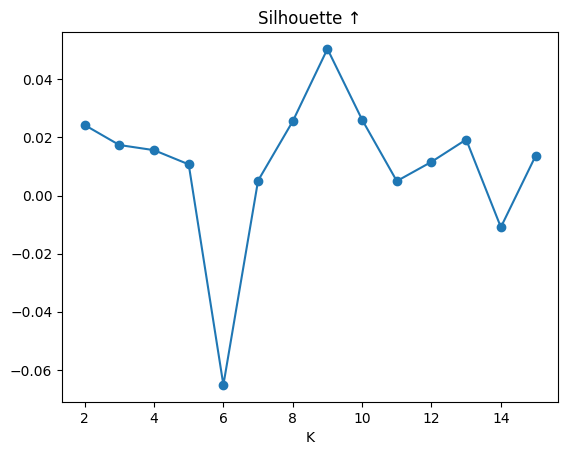

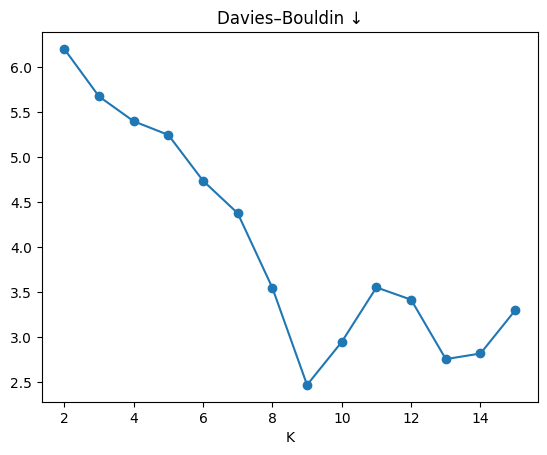

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

Ks = list(range(2, 16))
inertia, sil, db = [], [], []
for K in Ks:
    km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(embeddings)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(embeddings, km.labels_))
    db.append(davies_bouldin_score(embeddings, km.labels_))

plt.plot(Ks, inertia, marker='o'); plt.title("Elbow (inertia)"); plt.xlabel("K"); plt.show()
plt.plot(Ks, sil, marker='o'); plt.title("Silhouette ↑"); plt.xlabel("K"); plt.show()
plt.plot(Ks, db, marker='o'); plt.title("Davies–Bouldin ↓"); plt.xlabel("K"); plt.show()


In [ ]:
# ==== Setup ====
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
# Notebook backend
%matplotlib inline
import matplotlib.pyplot as plt


# Optional: HDBSCAN (gracefully skipped if not installed)
try:
    import hdbscan
    HAVE_HDBSCAN = True
except Exception:
    HAVE_HDBSCAN = False

# ===============================
# 1) Preprocess: L2-normalize + PCA
# ===============================
def preprocess_embeddings(X, pca_dims=50, random_state=42):
    # L2 normalize (aligns with cosine similarity)
    Xn = normalize(X)  # shape (N, D)
    # PCA to compact noise; cap at min(D, pca_dims)
    n_comp = min(Xn.shape[1], pca_dims)
    Xp = PCA(n_components=n_comp, random_state=random_state).fit_transform(Xn)
    return Xp

# ===============================
# 2) KMeans sweep + scoring
# ===============================
def evaluate_kmeans(X, K_min=2, K_max=15, random_state=42, n_init=10):
    Ks = list(range(K_min, K_max + 1))
    inertia, sil, db = [], [], []
    models = {}

    for K in Ks:
        km = KMeans(n_clusters=K, random_state=random_state, n_init=n_init).fit(X)
        labels = km.labels_
        models[K] = km
        inertia.append(km.inertia_)
        # handle degenerate cases
        sil.append(silhouette_score(X, labels) if len(set(labels)) > 1 else -1.0)
        db.append(davies_bouldin_score(X, labels) if len(set(labels)) > 1 else np.inf)

    return {
        "Ks": Ks,
        "inertia": np.array(inertia),
        "silhouette": np.array(sil),
        "db": np.array(db),
        "models": models
    }

# ===============================
# 3) Pick K (simple, robust rule)
#    - Prefer highest silhouette (if positive)
#    - Break ties by lowest DB
#    - If all silhouettes <= 0, pick min DB
# ===============================
def pick_best_K(scores):
    Ks = np.array(scores["Ks"])
    sil = scores["silhouette"]
    db  = scores["db"]

    if np.any(sil > 0):
        cand = Ks[sil == sil.max()]
        if len(cand) == 1:
            return int(cand[0])
        # tie-break with DB among tied Ks
        tie_idx = [np.where(Ks == k)[0][0] for k in cand]
        best = cand[np.argmin(db[tie_idx])]
        return int(best)
    else:
        # no clear separation, use lowest DB
        return int(Ks[np.argmin(db)])

# ===============================
# 4) Optional: HDBSCAN (no K)
# ===============================
def run_hdbscan(X, min_cluster_size=10, min_samples=None):
    if not HAVE_HDBSCAN:
        return None, None
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                min_samples=min_samples, metric='euclidean')
    labels = clusterer.fit_predict(X)
    # Score only on clustered points (exclude noise = -1)
    mask = labels != -1
    if mask.sum() > 1 and len(set(labels[mask])) > 1:
        sil = silhouette_score(X[mask], labels[mask])
        db  = davies_bouldin_score(X[mask], labels[mask])
    else:
        sil, db = None, None
    return labels, {"silhouette": sil, "db": db}

# ===============================
# 5) End-to-end runner
# ===============================
def cluster_words(embeddings, selected_words,
                  pca_dims=50, K_range=(2,15),
                  try_hdbscan=True, hdbscan_kwargs=None,
                  save_metadata_path=None):
    # preprocess
    X = preprocess_embeddings(embeddings, pca_dims=pca_dims)

    # sweep KMeans
    scores = evaluate_kmeans(X, K_min=K_range[0], K_max=K_range[1])
    best_K = pick_best_K(scores)
    best_km = scores["models"][best_K]
    kmeans_labels = best_km.labels_

    # optional HDBSCAN
    hdb = None
    if try_hdbscan:
        hdbscan_kwargs = hdbscan_kwargs or {"min_cluster_size": 10}
        hdb_labels, hdb_scores = run_hdbscan(X, **hdbscan_kwargs)
        if hdb_labels is not None:
            hdb = {"labels": hdb_labels, "scores": hdb_scores}

    # plots (quick diagnostics)
    Ks = scores["Ks"]
    plt.figure(); plt.plot(Ks, scores["inertia"], marker='o'); plt.title("Elbow (inertia)"); plt.xlabel("K"); plt.show()
    plt.figure(); plt.plot(Ks, scores["silhouette"], marker='o'); plt.title("Silhouette ↑"); plt.xlabel("K"); plt.show()
    plt.figure(); plt.plot(Ks, scores["db"], marker='o'); plt.title("Davies–Bouldin ↓"); plt.xlabel("K"); plt.show()

    # optional: save metadata.tsv for TensorBoard Projector with chosen KMeans labels
    if save_metadata_path:
        meta = {"word": selected_words, "kmeans_label": kmeans_labels}
        if hdb is not None:
            meta["hdbscan_label"] = hdb["labels"]
        pd.DataFrame(meta).to_csv(save_metadata_path, sep="\t", index=False)

    report = {
        "best_K": best_K,
        "kmeans_silhouette": float(silhouette_score(X, kmeans_labels)) if len(set(kmeans_labels)) > 1 else None,
        "kmeans_db": float(davies_bouldin_score(X, kmeans_labels)) if len(set(kmeans_labels)) > 1 else None,
        "hdbscan": hdb
    }
    return kmeans_labels, report

# ===============================
# 6) Example usage
# ===============================
# klabels, rpt = cluster_words(
#     embeddings,
#     selected_words,
#     pca_dims=50,
#     K_range=(2,15),
#     try_hdbscan=True,
#     hdbscan_kwargs={"min_cluster_size": max(5, len(selected_words)//50)},
#     save_metadata_path="projector_logs/metadata.tsv"  # optional
# )
# print("Best K:", rpt["best_K"])
# print("KMeans silhouette / DB:", rpt["kmeans_silhouette"], rpt["kmeans_db"])
# if rpt["hdbscan"] is not None:
#     print("HDBSCAN scores:", rpt["hdbscan"]["scores"])


/usr/local/lib/python3.12/dist-packages/hdbscan/plots.py:448: SyntaxWarning: invalid escape sequence '\l'
  axis.set_ylabel('$\lambda$ value')
/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
# Notebook backend
%matplotlib inline
import matplotlib.pyplot as plt


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN: clusters=13 (noise=139)  silhouette=0.5481482148170471  DB=0.6206346239776805
Spherical K-Means: bestK=4 silhouette(UMAP)=0.3107


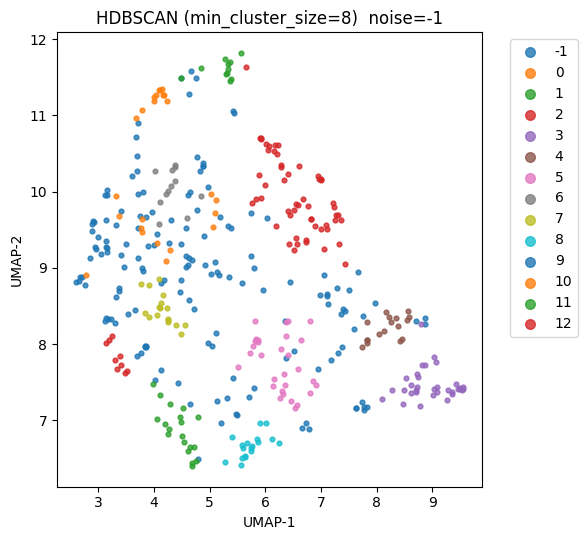

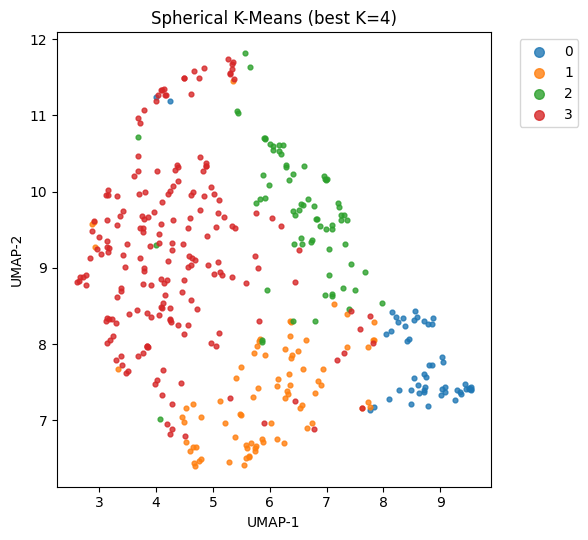

Saved: projector_logs/metadata.tsv


In [ ]:
# =========================
# 0) Installs (Colab-safe)
# =========================
!pip -q install umap-learn hdbscan sentence-transformers

# =========================
# 1) Imports & Colab setup
# =========================
%matplotlib inline
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans

import umap
import hdbscan
from sentence_transformers import SentenceTransformer

# Optional: quiet those HDBSCAN LaTeX warnings
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

# -------------------------------------------------------
# YOU MUST PROVIDE:
#   - selected_words : list[str] length N
#   - embeddings     : np.ndarray shape (N, D)
# If you don't like your current embeddings, set REEMBED=True below.
# -------------------------------------------------------
assert 'selected_words' in globals(), "Define `selected_words` (list of words)."
assert 'embeddings' in globals(), "Define `embeddings` (N x D array)."

# =========================
# 2) (Optional) Re-embed words with a stronger model
#    This changes the math source: use transformer embeddings
# =========================
REEMBED = False  # <- set True to regenerate embeddings from a transformer

if REEMBED:
    # NOTE: For isolated words, sentence models still help vs. older word2vec/glove
    # If you can, average contextual embeddings from real sentences for best results.
    model = SentenceTransformer("all-MiniLM-L6-v2")  # small, strong baseline
    embeddings = np.array(model.encode(selected_words, normalize_embeddings=False), dtype=np.float32)

# =========================
# 3) Cosine geometry prep:
#    L2-normalize (Euclidean ~ Cosine on unit sphere)
# =========================
X = normalize(embeddings)  # spherical space

# =========================
# 4) Denoise & shape manifold:
#    PCA -> UMAP (cosine), then cluster in UMAP space
#    Rationale:
#      - PCA reduces noise/global variance
#      - UMAP preserves local neighborhoods (cosine)
# =========================
PCA_DIMS = min(100, X.shape[1])
Xp = PCA(n_components=PCA_DIMS, random_state=42).fit_transform(X)

umap_10d = umap.UMAP(
    n_neighbors=15,       # increase for smoother, larger clusters; reduce for finer
    min_dist=0.0,         # tighter clusters
    n_components=10,      # 10D space for clustering
    metric="cosine",
    random_state=42
)
U10 = umap_10d.fit_transform(Xp)

# Also make a 2D projection for visualization only
umap_2d = umap.UMAP(
    n_neighbors=15, min_dist=0.0, n_components=2, metric="cosine", random_state=42
)
U2 = umap_2d.fit_transform(Xp)

# =========================
# 5) Cluster with HDBSCAN
#    Pros: variable cluster sizes, noise points (-1), no need to pick K
#    Tip: tune min_cluster_size to control granularity.
# =========================
min_cluster_size = max(8, len(selected_words)//50)  # heuristic
hdb = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean')
# (use euclidean in UMAP space; UMAP already used cosine)
hdb_labels = hdb.fit_predict(U10)

# Evaluate on non-noise points
mask = hdb_labels != -1
if mask.sum() > 1 and len(set(hdb_labels[mask])) > 1:
    hdb_sil = silhouette_score(U10[mask], hdb_labels[mask])
    hdb_db  = davies_bouldin_score(U10[mask], hdb_labels[mask])
else:
    hdb_sil, hdb_db = None, None

print(f"HDBSCAN: clusters={len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)} "
      f"(noise={np.sum(hdb_labels==-1)})  silhouette={hdb_sil}  DB={hdb_db}")

# =========================
# 6) (Alternative) Spherical K-Means (cosine K-means)
#    Do KMeans on normalized vectors (≈ cosine k-means).
#    We'll choose K by maximizing silhouette on UMAP space.
# =========================
K_MIN, K_MAX = 2, 15
bestK, best_sil, best_model, best_labels = None, -1.0, None, None
for K in range(K_MIN, K_MAX+1):
    km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X)  # X is unit-normalized
    labels = km.labels_
    if len(set(labels)) > 1:
        # score on UMAP space to reflect manifold geometry
        s = silhouette_score(U10, labels)
        if s > best_sil:
            bestK, best_sil, best_model, best_labels = K, s, km, labels

print(f"Spherical K-Means: bestK={bestK} silhouette(UMAP)={best_sil:.4f}")

# =========================
# 7) Visualization
# =========================
def plot_umap(U2, labels, title):
    plt.figure(figsize=(6.0, 5.5))
    uniq = np.unique(labels)
    for lab in uniq:
        idx = labels == lab
        plt.scatter(U2[idx, 0], U2[idx, 1], s=12, alpha=0.8, label=str(lab))
    plt.title(title)
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
    # Keep legend small:
    if len(uniq) <= 15:
        plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_umap(U2, hdb_labels, f"HDBSCAN (min_cluster_size={min_cluster_size})  noise=-1")
if best_labels is not None:
    plot_umap(U2, best_labels, f"Spherical K-Means (best K={bestK})")

# =========================
# 8) Save labels for TensorBoard Projector
# =========================
LOG_DIR = "projector_logs"
os.makedirs(LOG_DIR, exist_ok=True)
meta = {"word": selected_words}
meta["hdbscan_label"] = hdb_labels
if best_labels is not None:
    meta["spherical_kmeans_label"] = best_labels
pd.DataFrame(meta).to_csv(os.path.join(LOG_DIR, "metadata.tsv"), sep="\t", index=False)

print("Saved:", os.path.join(LOG_DIR, "metadata.tsv"))


In [ ]:
rng = np.random.default_rng(42)

def bootstrap_mean(x, B=2000):
    x = np.asarray(x, float)
    bs = [rng.choice(x, size=len(x), replace=True).mean() for _ in range(B)]
    return np.mean(bs), np.quantile(bs, [0.025, 0.975])

m, (lo, hi) = bootstrap_mean(within)
print(f"Within-cluster mean cosine ~ {m:.3f} (95% CI [{lo:.3f}, {hi:.3f}])")


Within-cluster mean cosine ~ 0.257 (95% CI [0.256, 0.258])


In [ ]:
obs = np.nanmean(within) - np.nanmean(across)
all_vals = np.array(within + across)
n_w = len(within)

B = 2000
more_extreme = 0
for _ in range(B):
    rng.shuffle(all_vals)
    diff = np.mean(all_vals[:n_w]) - np.mean(all_vals[n_w:])
    if diff >= obs:
        more_extreme += 1
p = (more_extreme + 1) / (B + 1)
print(f"Permutation p-value for (within > across): {p:.4f}")


Permutation p-value for (within > across): 0.0005


In [ ]:
from sklearn.metrics.pairwise import cosine_distances
K = 10
D = cosine_distances(embeddings)
np.fill_diagonal(D, np.inf)
nns = np.argsort(D, axis=1)[:, :K]
hub_counts = np.bincount(nns.ravel(), minlength=len(embeddings))
top_hubs = np.argsort(-hub_counts)[:10]
print("Top hubs:", [selected_words[i] for i in top_hubs], hub_counts[top_hubs])


Top hubs: ['page', 'wherefore', 'things', 'thing', 'likewise', 'seeing', 'notwithstanding', 'body', 'regard', 'onely'] [129  79  77  69  66  65  64  52  48  41]


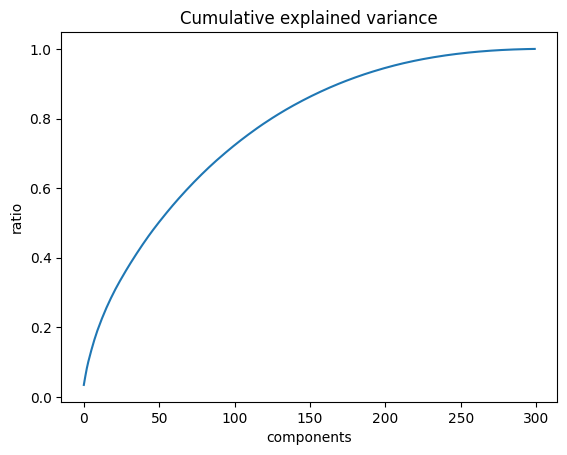

In [ ]:
from sklearn.decomposition import PCA
pca = PCA().fit(embeddings)
var = np.cumsum(pca.explained_variance_ratio_)
plt.plot(var); plt.title("Cumulative explained variance"); plt.xlabel("components"); plt.ylabel("ratio"); plt.show()


In [ ]:
from google.colab import files

uploaded = files.upload()  # Pick your file interactively


Saving metadata.tsv to metadata.tsv


In [ ]:
import pandas as pd

metadata_df = pd.read_csv("metadata.tsv", sep="\t")


In [ ]:
print(metadata_df.columns.tolist())
metadata_df.head()


['word', 'cluster', 'freq']


,word,cluster,freq
0,page,3,32250
1,things,3,27950
2,body,1,23044
3,great,1,22580
4,water,2,22034


In [ ]:
from google.colab import files

uploaded = files.upload()  # Pick your file interactively

Saving vectors.tsv to vectors.tsv


In [ ]:
from google.colab import files

uploaded = files.upload()  # Pick your file interactively

Saving word_embeddings_tsne.csv to word_embeddings_tsne.csv


embeddings shape from vectors.tsv: (400, 300)
t-SNE CSV columns: ['word', 'x', 'y', 'cluster']
   word          x         y  cluster
0   aaa -23.707983  9.795731        2
1  aaaa -24.416407  9.468786        2
2  aabi   2.457572  2.498672        0


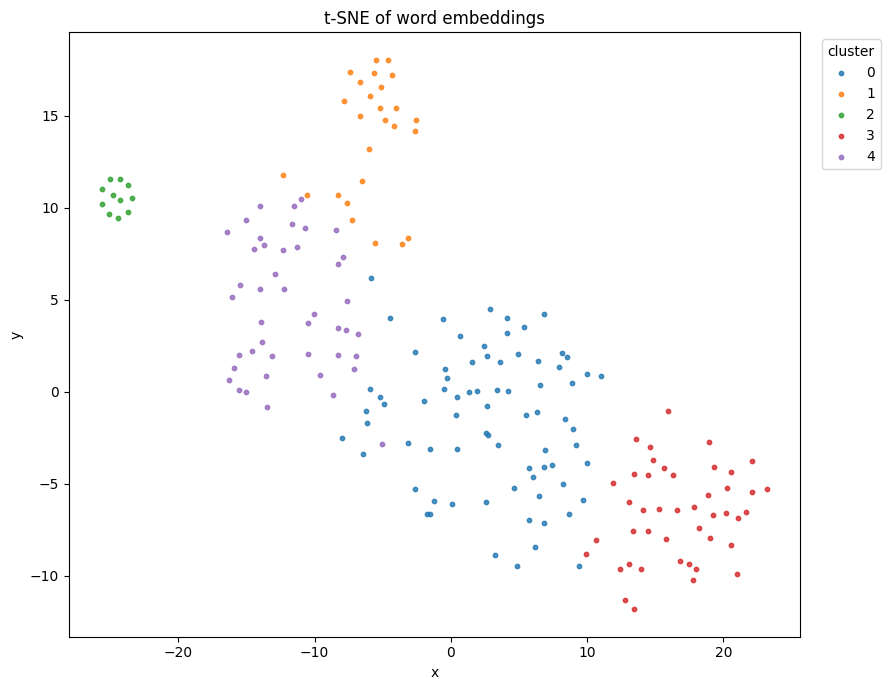

In [ ]:
# --- 1) Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

# --- 2) Load files ---
# Adjust names if needed
TSNE_CSV = "word_embeddings_tsne.csv"
VECTORS_TSV = "vectors.tsv"
OPTIONAL_METADATA_TSV = "metadata.tsv"  # only if i have it (for words)

# Load embeddings (vectors.tsv): usually no header, tab-separated
# If file DOES have a header, set header=0 instead.
vec_df = pd.read_csv(VECTORS_TSV, sep="\t", header=None)
embeddings = vec_df.to_numpy(dtype=np.float32)
print("embeddings shape from vectors.tsv:", embeddings.shape)

# Load t-SNE CSV (assume it has at least x,y and maybe 'word','cluster','freq')
tsne_df = pd.read_csv(TSNE_CSV)
print("t-SNE CSV columns:", tsne_df.columns.tolist())
print(tsne_df.head(3))

# Try to identify x/y column names
x_col_candidates = [c for c in tsne_df.columns if c.lower() in ("x","tsne-2d-one","tsne_x","umap_x")]
y_col_candidates = [c for c in tsne_df.columns if c.lower() in ("y","tsne-2d-two","tsne_y","umap_y")]
if not x_col_candidates or not y_col_candidates:
    raise ValueError("Could not find x/y columns in your t-SNE CSV. Please tell me the exact column names.")

xcol, ycol = x_col_candidates[0], y_col_candidates[0]

# Optional: load words from metadata.tsv if present and not already in tsne_df
words = None
try:
    meta_df = pd.read_csv(OPTIONAL_METADATA_TSV, sep="\t")
    if "word" in meta_df.columns and "word" not in tsne_df.columns:
        words = meta_df["word"].tolist()
        print("Loaded words from metadata.tsv")
except Exception as e:
    pass

# --- 3) Plot the t-SNE that i already have ---
plt.figure(figsize=(9,7))
if "cluster" in tsne_df.columns:
    # color by cluster if available
    clabs = tsne_df["cluster"].astype(str).values
    uniq = sorted(tsne_df["cluster"].astype(str).unique())
    for u in uniq:
        idx = (clabs == u)
        plt.scatter(tsne_df.loc[idx, xcol], tsne_df.loc[idx, ycol], s=10, alpha=0.8, label=str(u))
    if len(uniq) <= 20:
        plt.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
else:
    # plain scatter
    plt.scatter(tsne_df[xcol], tsne_df[ycol], s=10, alpha=0.8)

plt.title("t-SNE of word embeddings")
plt.xlabel(xcol); plt.ylabel(ycol)

# Label only the top-N frequent words if 'freq' and 'word' columns exist
if "freq" in tsne_df.columns and "word" in tsne_df.columns:
    N_LABELS = 50
    top_idx = tsne_df["freq"].nlargest(N_LABELS).index
    for i in top_idx:
        plt.text(tsne_df.loc[i, xcol], tsne_df.loc[i, ycol], str(tsne_df.loc[i, "word"]),
                 fontsize=8, alpha=0.85)
plt.tight_layout()
plt.show()

# --- 4) OPTIONAL: run new math (PCA→UMAP) from vectors.tsv and plot that too ---
RUN_NEW_UMAP = False  # set True to compute UMAP from vectors.tsv
if RUN_NEW_UMAP:
    from sklearn.decomposition import PCA
    import umap

    # Cosine geometry
    Xn = normalize(embeddings)
    # PCA to 90% variance
    pca = PCA(n_components=0.90, svd_solver="full", random_state=42)
    Xp = pca.fit_transform(Xn)
    print("PCA shape:", Xp.shape)

    # UMAP 2D
    U2 = umap.UMAP(n_neighbors=15, min_dist=0.0, n_components=2,
                   metric="cosine", random_state=42).fit_transform(Xp)

    plt.figure(figsize=(9,7))
    plt.scatter(U2[:,0], U2[:,1], s=10, alpha=0.8)
    plt.title("UMAP (from vectors.tsv)")
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
    plt.tight_layout(); plt.show()


In [ ]:
N = len(metadata_df)
print("rows / words:", N)
print(metadata_df.shape)      # (rows, 3) → rows should equal N
metadata_df.head(20)          # just to *show* more than 5


rows / words: 400
(400, 3)


,word,cluster,freq
0,page,3,32250
1,things,3,27950
2,body,1,23044
3,great,1,22580
4,water,2,22034
5,hath,3,21393
6,parts,1,20128
7,nature,3,19890
8,make,1,19082
9,time,3,18160


from matplotlib import pyplot as plt
_df_0['cluster'].plot(kind='hist', bins=20, title='cluster')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['freq'].plot(kind='hist', bins=20, title='freq')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='cluster', y='freq', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['cluster'].plot(kind='line', figsize=(8, 4), title='cluster')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_4['freq'].plot(kind='line', figsize=(8, 4), title='freq')
plt.gca().spines[['top', 'right']].set_visible(False)

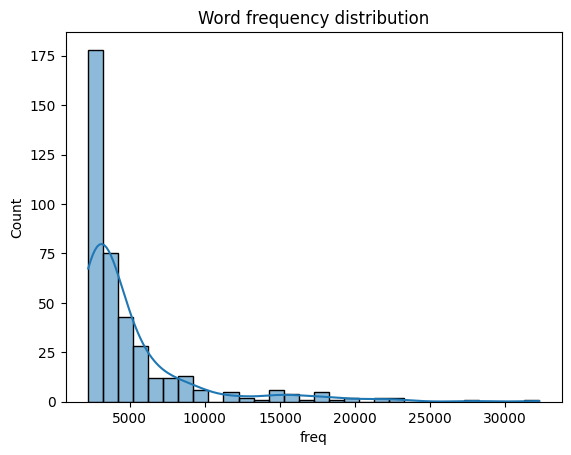

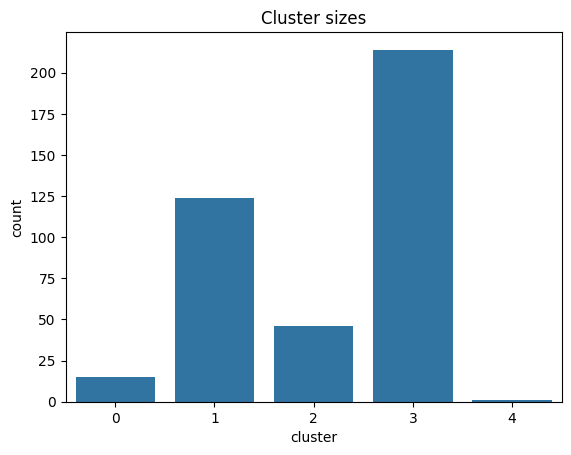

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of frequencies
sns.histplot(metadata_df["freq"], bins=30, kde=True)
plt.title("Word frequency distribution")
plt.show()

# Counts per cluster
sns.countplot(x="cluster", data=metadata_df)
plt.title("Cluster sizes")
plt.show()


In [ ]:
# Only if you need to (e.g., to run PCA/UMAP/t-SNE)
!pip -q install sentence-transformers
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = np.array(model.encode(words, normalize_embeddings=False), dtype=np.float32)
print("embeddings shape:", embeddings.shape)  # (N, D)  ← uses ALL words


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

embeddings shape: (400, 384)


PCA shape: (400, 145)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2D shape: (400, 2)


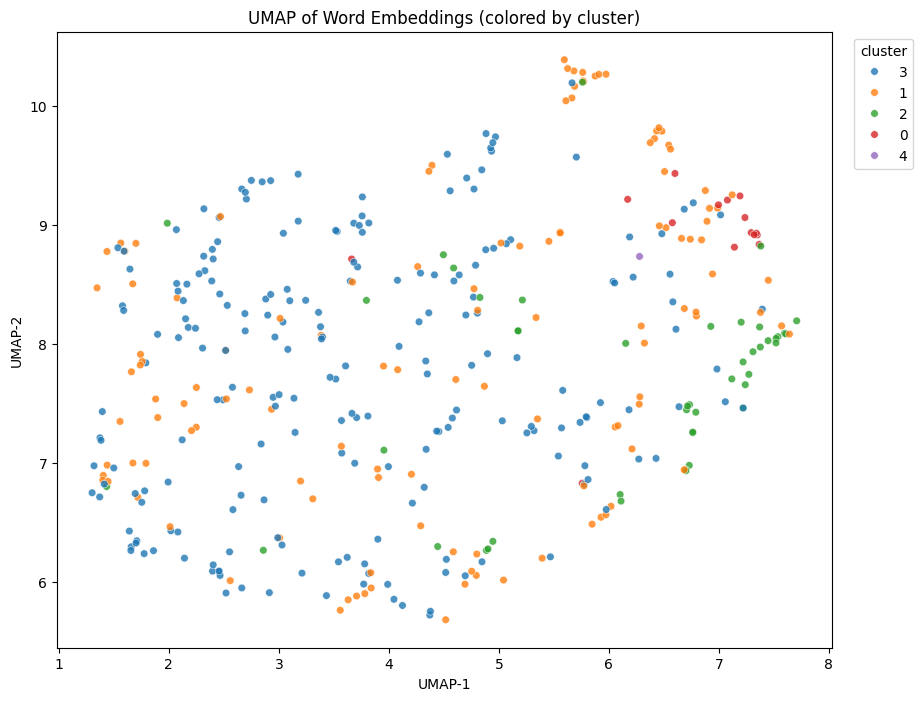


=== Top words per cluster ===
Cluster 0: ['blood', 'stomach', 'heart', 'brain', 'veins', 'vessels', 'womb', 'liver', 'bloud', 'nerves']
Cluster 1: ['body', 'great', 'parts', 'make', 'good', 'use', 'reason', 'matter', 'little', 'cause']
Cluster 2: ['water', 'half', 'salt', 'wine', 'ounce', 'white', 'oyl', 'dram', 'ounces', 'gold']
Cluster 3: ['page', 'things', 'hath', 'nature', 'time', 'man', 'like', 'doth', 'shall', 'god']
Cluster 4: ['cum']

=== Clustering Quality ===
Silhouette score (higher=better): -0.017
Davies–Bouldin score (lower=better): 6.295


In [ ]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
import umap
from sklearn.metrics import silhouette_score, davies_bouldin_score

# --- 1. Normalize embeddings (cosine geometry) ---
X_norm = normalize(embeddings)

# --- 2. PCA to reduce dimensionality (retain 90% variance) ---
pca = PCA(n_components=0.90, svd_solver="full", random_state=42)
Xp = pca.fit_transform(X_norm)
print("PCA shape:", Xp.shape)

# --- 3. UMAP to 2D ---
umap_2d = umap.UMAP(
    n_neighbors=15, min_dist=0.0, n_components=2,
    metric="cosine", random_state=42
)
U2 = umap_2d.fit_transform(Xp)
print("UMAP 2D shape:", U2.shape)

# --- 4. UMAP plot with cluster coloring ---
plt.figure(figsize=(10,8))
sns.scatterplot(
    x=U2[:,0], y=U2[:,1],
    hue=metadata_df["cluster"].astype(str),
    palette="tab10", s=30, alpha=0.8
)
plt.title("UMAP of Word Embeddings (colored by cluster)")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

# --- 5. Top 10 frequent words per cluster ---
print("\n=== Top words per cluster ===")
for c in sorted(metadata_df["cluster"].unique()):
    sub = metadata_df[metadata_df["cluster"]==c]
    top_words = sub.sort_values("freq", ascending=False).head(10)["word"].tolist()
    print(f"Cluster {c}: {top_words}")

# --- 6. Clustering quality scores ---
sil = silhouette_score(embeddings, metadata_df["cluster"])
db = davies_bouldin_score(embeddings, metadata_df["cluster"])
print("\n=== Clustering Quality ===")
print(f"Silhouette score (higher=better): {sil:.3f}")
print(f"Davies–Bouldin score (lower=better): {db:.3f}")


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import umap, hdbscan
import matplotlib.pyplot as plt

# --- 1) Prep: cosine geometry + PCA(90%) + UMAP(10D) ---
Xn = normalize(embeddings)
Xp = PCA(n_components=0.90, svd_solver="full", random_state=42).fit_transform(Xn)
U10 = umap.UMAP(n_neighbors=15, min_dist=0.0, n_components=10,
                metric="cosine", random_state=42).fit_transform(Xp)

def score_labels(X, labels):
    """Return (silhouette, db) or (None, None) if <2 clusters."""
    labs = np.array(labels)
    uniq = np.unique(labs[labs != -1])  # exclude noise
    if len(uniq) < 2:
        return None, None
    mask = labs != -1
    return (silhouette_score(X[mask], labs[mask]),
            davies_bouldin_score(X[mask], labs[mask]))

# --- 2) Small grid search for HDBSCAN that yields >=2 clusters ---
candidates = []  # each item will be a dict

N = len(embeddings)
grid_mcs = [5, 8, 12, max(15, N//40), max(20, N//30)]
grid_ms  = [None, 1, 2, 5]

for mcs in grid_mcs:
    for ms in grid_ms:
        clus = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="euclidean")
        labels = clus.fit_predict(U10)  # cluster in UMAP-10D space
        sil, db = score_labels(U10, labels)  # (None, None) if <2 clusters

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int(np.sum(labels == -1))

        candidates.append({
            "sil": sil,                     # may be None
            "db": db,                       # may be None
            "mcs": mcs,
            "ms": ms,
            "labels": labels,
            "k": n_clusters,
            "noise": n_noise,
        })

# Pick best by: highest silhouette, then lowest DB (ignore None safely)
def cand_key(c):
    sil = c["sil"]
    db  = c["db"]
    # map None -> very bad values so they lose
    sil_key = sil if sil is not None else -1.0
    db_key  = db  if db  is not None else 1e9
    # we want max sil, min db; combine as tuple
    return (sil_key, -db_key)

best = max(candidates, key=cand_key)

best_sil = best["sil"]
best_db  = best["db"]
best_mcs = best["mcs"]
best_ms  = best["ms"]
best_labels = best["labels"]
best_k   = best["k"]
best_noise = best["noise"]

print(f"HDBSCAN best: min_cluster_size={best_mcs}, min_samples={best_ms}, "
      f"clusters={best_k}, noise={best_noise}, silhouette={best_sil}, DB={best_db}")



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/

HDBSCAN best: min_cluster_size=8, min_samples=None, clusters=11, noise=130, silhouette=0.5451489090919495, DB=0.6023043787221414


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
!pip -q install spacy
!python -m spacy download en_core_web_sm

import spacy
nlp = spacy.load("en_core_web_sm")

def pos_tag_word(w):
    doc = nlp(w)
    return doc[0].pos_ if len(doc) else "X"

metadata_df["tag"] = metadata_df["word"].astype(str).apply(pos_tag_word)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 38.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
print(metadata_df.columns.tolist())
metadata_df.head()


['word', 'cluster', 'freq']


,word,cluster,freq
0,page,3,32250
1,things,3,27950
2,body,1,23044
3,great,1,22580
4,water,2,22034


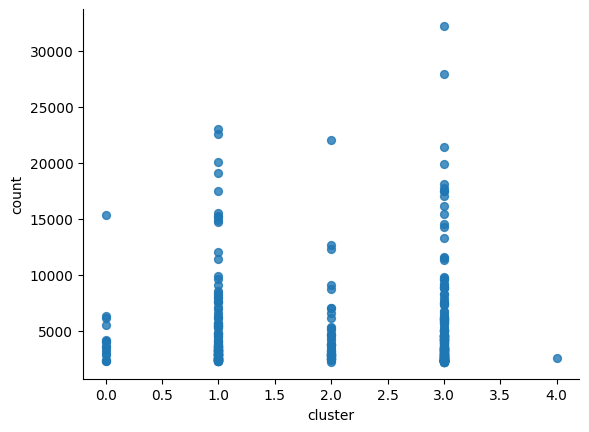

In [ ]:
# @title cluster vs count

from matplotlib import pyplot as plt
metadata_df.plot(kind='scatter', x='cluster', y='count', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
for c in sorted(metadata_df["cluster"].unique()):
    top = metadata_df[metadata_df["cluster"] == c].sort_values("freq", ascending=False).head(10)
    print(f"\nCluster {c} top words:", top["word"].tolist())



Cluster 0 top words: ['blood', 'stomach', 'heart', 'brain', 'veins', 'vessels', 'womb', 'liver', 'bloud', 'nerves']

Cluster 1 top words: ['body', 'great', 'parts', 'make', 'good', 'use', 'reason', 'matter', 'little', 'cause']

Cluster 2 top words: ['water', 'half', 'salt', 'wine', 'ounce', 'white', 'oyl', 'dram', 'ounces', 'gold']

Cluster 3 top words: ['page', 'things', 'hath', 'nature', 'time', 'man', 'like', 'doth', 'shall', 'god']

Cluster 4 top words: ['cum']


In [ ]:
metadata_df["cluster"].value_counts()

,count
cluster,
3,214
1,124
2,46
0,15
4,1


In [ ]:
metadata_clean = metadata_df[metadata_df["cluster"] != 4]


Clusters after cleaning: cluster
3    214
1    124
2     46
0     15
Name: count, dtype: int64


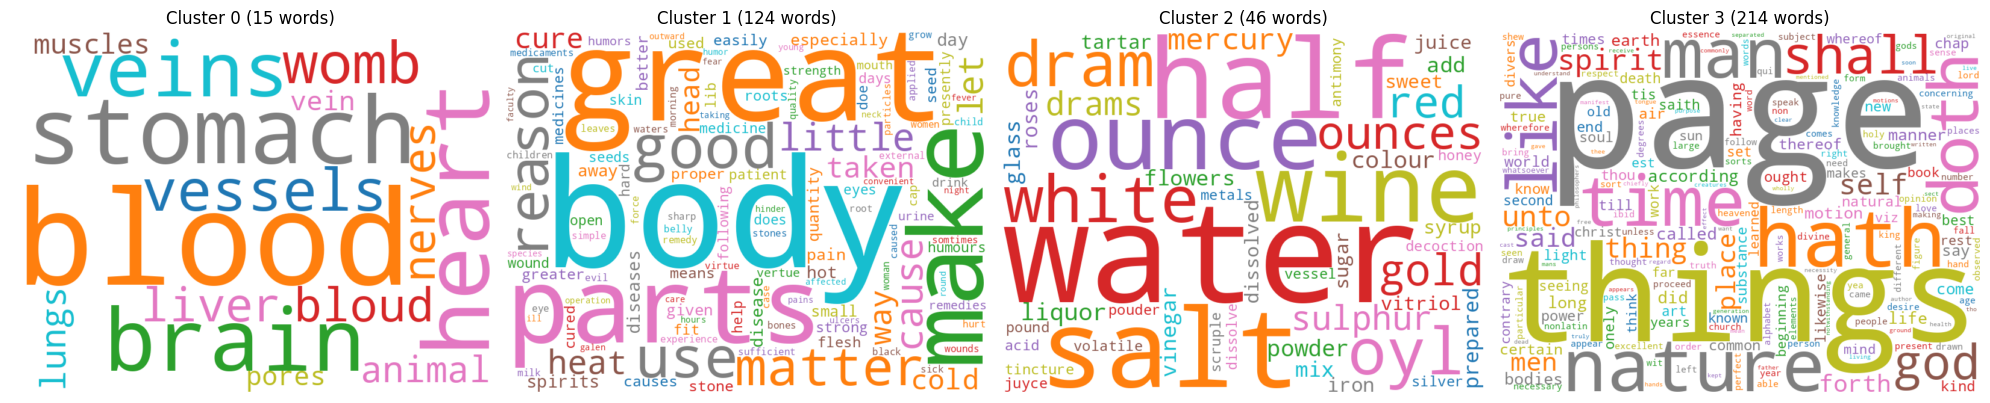

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1) Remove tiny cluster (size=1)
metadata_clean = metadata_df[metadata_df["cluster"] != 4].copy()
print("Clusters after cleaning:", metadata_clean["cluster"].value_counts())

# 2) Build word clouds per cluster
clusters = sorted(metadata_clean["cluster"].unique())

fig, axes = plt.subplots(1, len(clusters), figsize=(20, 6))

for i, c in enumerate(clusters):
    sub = metadata_clean[metadata_clean["cluster"] == c]

    # make frequency dict {word: freq}
    freq_dict = dict(zip(sub["word"], sub["freq"]))

    wc = WordCloud(width=800, height=600,
                   background_color="white",
                   colormap="tab10").generate_from_frequencies(freq_dict)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"Cluster {c} ({len(sub)} words)", fontsize=12)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


Filtered words by freq quantiles [0.01, 0.99]: kept 392 / 400


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings shape (filtered): (392, 384)
PCA -> kept 144 comps for 0.901 variance


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWar

HDBSCAN best -> mcs=8, ms=None, k=11, noise=162, sil=0.4790365397930145, db=0.7113422879768813


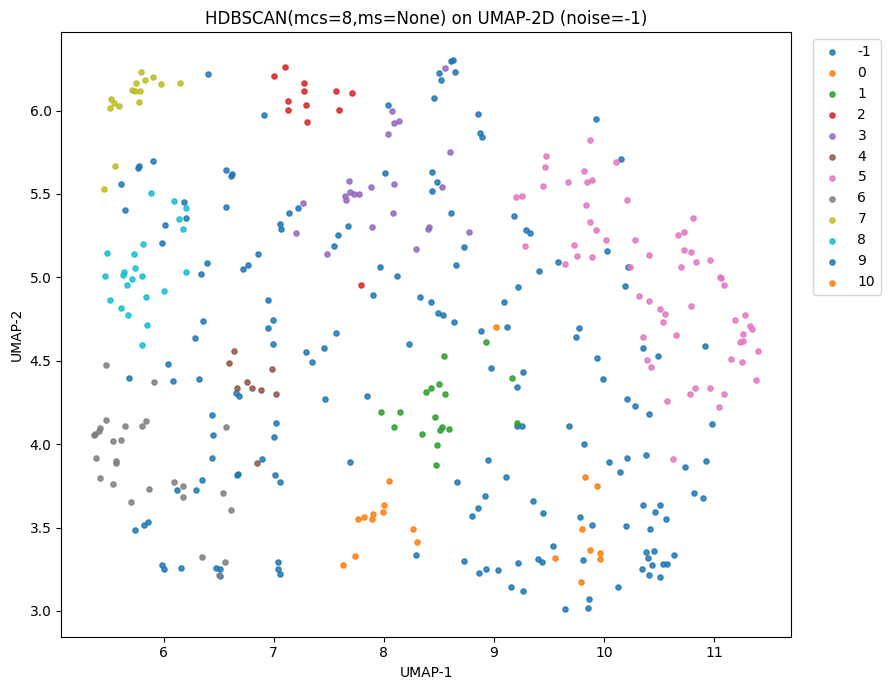

Final silhouette (non-noise): 0.47903654
Final Davies–Bouldin (non-noise): 0.7113422879768813

Cluster sizes:
cluster_new
-1     162
 0      12
 1      18
 2      12
 3      24
 4       9
 5      63
 6      28
 7      16
 8      23
 9      17
 10      8
Name: count, dtype: int64

Top 10 words per cluster:
Cluster 0: ['parts', 'little', 'half', 'small', 'quantity', 'fit', 'length', 'number', 'large', 'figure']
Cluster 1: ['time', 'long', 'day', 'away', 'times', 'old', 'est', 'rest', 'years', 'days']
Cluster 2: ['self', 'life', 'world', 'death', 'desire', 'evil', 'heaven', 'fear', 'living', 'dead']
Cluster 3: ['oyl', 'saith', 'book', 'learned', 'knowledge', 'people', 'divine', 'king', 'wit', 'speak']
Cluster 4: ['nature', 'seed', 'flowers', 'seeds', 'roses', 'grow', 'leaves', 'plants', 'space']
Cluster 5: ['hath', 'man', 'like', 'good', 'shall', 'unto', 'said', 'way', 'according', 'manner']
Cluster 6: ['water', 'salt', 'wine', 'light', 'substance', 'stone', 'gold', 'red', 'sulphur', 'mer

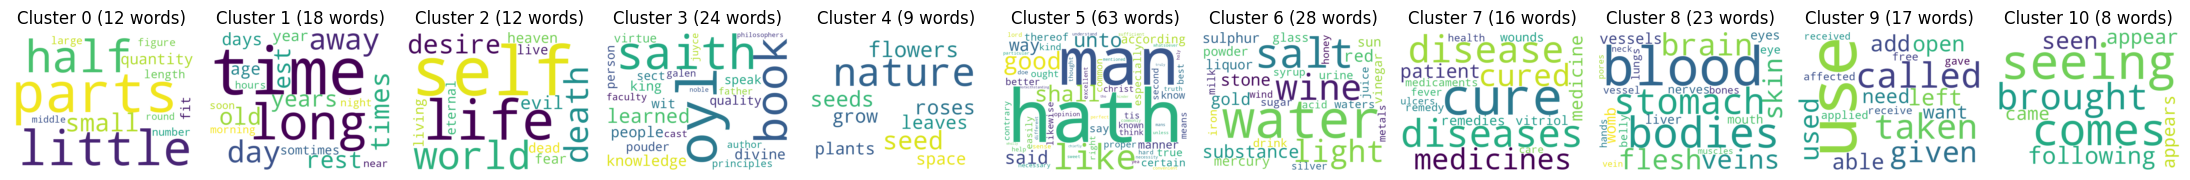

Saved: clusters_new.tsv


In [ ]:
# ============================
# 0) Setup & Imports (Colab)
# ============================
# Minimal, robust dependencies
!pip -q install sentence-transformers umap-learn hdbscan wordcloud

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

from sentence_transformers import SentenceTransformer
import umap, hdbscan
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

# ============================
# 1) Input: metadata_df
# ============================
# Expect metadata_df in memory; if not, try to read it from metadata.tsv
if "metadata_df" not in globals():
    try:
        metadata_df = pd.read_csv("metadata.tsv", sep="\t")
        print("Loaded metadata_df from metadata.tsv")
    except Exception as e:
        raise ValueError("metadata_df not found in memory and metadata.tsv not present. "
                         "Please load your file into a DataFrame called metadata_df.") from e

needed_cols = {"word", "freq"}
missing = needed_cols - set(map(str, metadata_df.columns))
if missing:
    raise ValueError(f"metadata_df is missing columns: {missing}. "
                     f"Expected at least {needed_cols} (cluster optional).")

# Clean & ensure types
metadata_df = metadata_df.dropna(subset=["word", "freq"]).copy()
metadata_df["word"] = metadata_df["word"].astype(str)
metadata_df["freq"] = pd.to_numeric(metadata_df["freq"], errors="coerce")
metadata_df = metadata_df.dropna(subset=["freq"]).reset_index(drop=True)

# ============================
# 2) Frequency filtering (denoise)
#    Drop extreme tails to improve clustering
# ============================
LOW_Q, HIGH_Q = 0.01, 0.99     # keep middle 98% by freq (adjustable)
lo, hi = metadata_df["freq"].quantile([LOW_Q, HIGH_Q]).values
mask = (metadata_df["freq"] >= lo) & (metadata_df["freq"] <= hi)
df_filt = metadata_df.loc[mask].reset_index(drop=True)

print(f"Filtered words by freq quantiles [{LOW_Q:.2f}, {HIGH_Q:.2f}]: "
      f"kept {len(df_filt)} / {len(metadata_df)}")

# ============================
# 3) Embeddings
#    Use existing `embeddings` (aligned to metadata_df rows) if present,
#    else encode from the filtered words.
# ============================
def build_embeddings(words, model_name="all-MiniLM-L6-v2"):
    model = SentenceTransformer(model_name)
    arr = np.array(model.encode(words, normalize_embeddings=False), dtype=np.float32)
    return arr

# If user already has `embeddings`, try to subset/align; else compute fresh
if "embeddings" in globals():
    emb = np.asarray(embeddings)
    if emb.shape[0] == len(metadata_df):
        emb_filt = emb[mask]  # align with df_filt
    elif emb.shape[0] == len(df_filt):
        emb_filt = emb
    else:
        raise ValueError("Existing `embeddings` shape does not match metadata_df "
                         "or filtered df_filt. Provide matching embeddings or let the code re-embed.")
else:
    words = df_filt["word"].tolist()
    emb_filt = build_embeddings(words)  # (N, D)

print("Embeddings shape (filtered):", emb_filt.shape)

# ============================
# 4) Cosine geometry → auto-PCA → UMAP
# ============================
def pca_auto_cosine(E, variance_target=0.90, random_state=42):
    X = normalize(E)  # cosine geometry
    pca = PCA(n_components=variance_target, svd_solver="full", random_state=random_state)
    Xp = pca.fit_transform(X)
    print(f"PCA -> kept {pca.n_components_} comps for {pca.explained_variance_ratio_.sum():.3f} variance")
    return X, Xp, pca

X_unit, Xp, pca = pca_auto_cosine(emb_filt, variance_target=0.90)

# UMAP spaces
umap10 = umap.UMAP(n_neighbors=30, min_dist=0.0, n_components=10,
                   metric="cosine", random_state=42)
U10 = umap10.fit_transform(Xp)

umap2 = umap.UMAP(n_neighbors=30, min_dist=0.0, n_components=2,
                  metric="cosine", random_state=42)
U2 = umap2.fit_transform(Xp)

# ============================
# 5) HDBSCAN mini-grid (safe) + fallback spherical K-Means
# ============================
def score_non_noise(Xspace, labels):
    labs = np.asarray(labels)
    mask = labs != -1
    uniq = np.unique(labs[mask])
    if len(uniq) < 2 or mask.sum() < 3:
        return None, None
    return (silhouette_score(Xspace[mask], labs[mask]),
            davies_bouldin_score(Xspace[mask], labs[mask]))

N = len(df_filt)
grid_mcs = [max(5, N//80), max(8, N//60), max(12, N//40)]
grid_ms  = [None, 1, 2, 5]

candidates = []
for mcs in grid_mcs:
    for ms in grid_ms:
        clus = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="euclidean")
        labels = clus.fit_predict(U10)       # cluster in UMAP-10D
        sil, db = score_non_noise(U10, labels)
        n_cl = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        candidates.append({
            "sil": sil, "db": db, "mcs": mcs, "ms": ms,
            "labels": labels, "k": n_cl, "noise": n_noise
        })

def cand_key(c):
    sil = c["sil"] if c["sil"] is not None else -1.0
    db  = c["db"]  if c["db"]  is not None else 1e9
    return (sil, -db)  # max by sil, then min db

best = max(candidates, key=cand_key)
print(f"HDBSCAN best -> mcs={best['mcs']}, ms={best['ms']}, "
      f"k={best['k']}, noise={best['noise']}, "
      f"sil={best['sil']}, db={best['db']}")

final_labels = best["labels"]
final_method = f"HDBSCAN(mcs={best['mcs']},ms={best['ms']})"

# Fallback if < 2 clusters
if best["k"] < 2:
    bestK, bestSil, bestLabs = None, -1.0, None
    for K in range(2, 10):
        km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_unit)
        # score on manifold space
        s = silhouette_score(U10, km.labels_)
        if s > bestSil:
            bestK, bestSil, bestLabs = K, s, km.labels_
    final_labels = bestLabs
    final_method = f"Spherical K-Means(K={bestK})"
    print(f"Fallback used -> {final_method}, silhouette(UMAP-10D)={bestSil:.4f}")

# ============================
# 6) Visualization + Quality + Top words
# ============================
# UMAP colored by cluster
plt.figure(figsize=(9,7))
for lab in np.unique(final_labels):
    idx = final_labels == lab
    plt.scatter(U2[idx,0], U2[idx,1], s=14, alpha=0.85, label=str(lab))
plt.title(f"{final_method} on UMAP-2D (noise=-1)")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
if len(np.unique(final_labels)) <= 20:
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

# Quality (exclude noise if any)
sil, db = score_non_noise(U10, final_labels)
print("Final silhouette (non-noise):", sil)
print("Final Davies–Bouldin (non-noise):", db)

# Build a summary with words/freq aligned to filtered set
out_df = df_filt[["word", "freq"]].copy()
out_df["cluster_new"] = final_labels

print("\nCluster sizes:")
print(out_df["cluster_new"].value_counts().sort_index())

print("\nTop 10 words per cluster:")
for c in sorted([x for x in out_df["cluster_new"].unique() if x != -1]):
    sub = out_df[out_df["cluster_new"] == c].sort_values("freq", ascending=False).head(10)
    print(f"Cluster {c}: {sub['word'].tolist()}")

# ============================
# 7) Optional: Word clouds per cluster
# ============================
try:
    clusters = sorted([x for x in out_df["cluster_new"].unique() if x != -1])
    fig, axes = plt.subplots(1, len(clusters), figsize=(22, 8))
    if len(clusters) == 1:
        axes = [axes]
    for ax, c in zip(axes, clusters):
        sub = out_df[out_df["cluster_new"] == c]
        freq_dict = dict(zip(sub["word"], sub["freq"]))
        if len(freq_dict) == 0:
            ax.axis("off"); ax.set_title(f"Cluster {c} (empty)"); continue
        wc = WordCloud(width=800, height=600, background_color="white").generate_from_frequencies(freq_dict)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(f"Cluster {c} ({len(sub)} words)")
        ax.axis("off")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Word cloud step skipped:", e)

# ============================
# 8) Save outputs (optional)
# ============================
out_df.to_csv("clusters_new.tsv", sep="\t", index=False)
print("Saved: clusters_new.tsv")


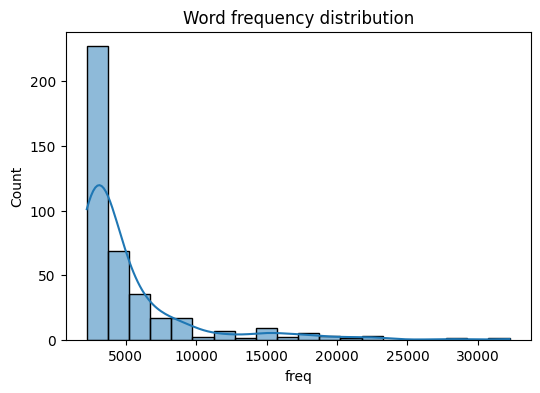

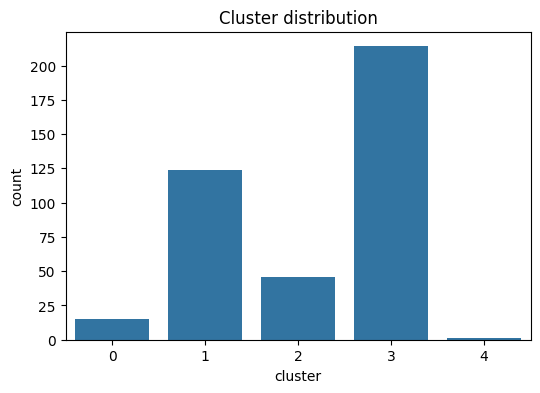

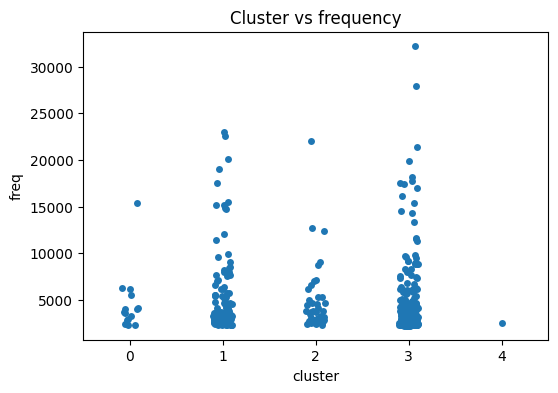

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


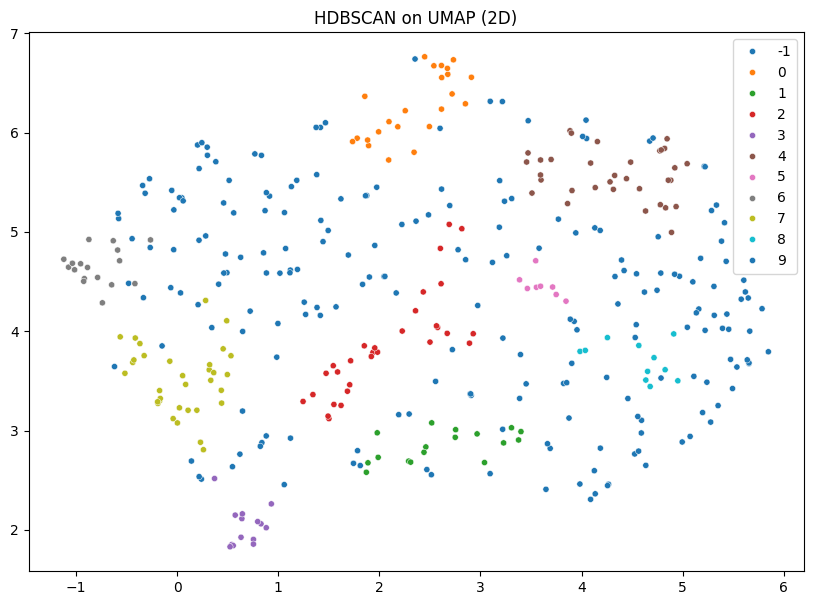

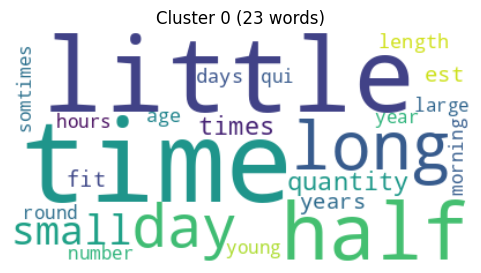

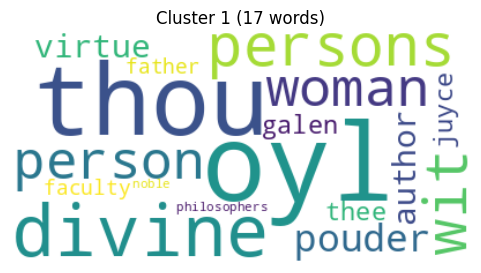

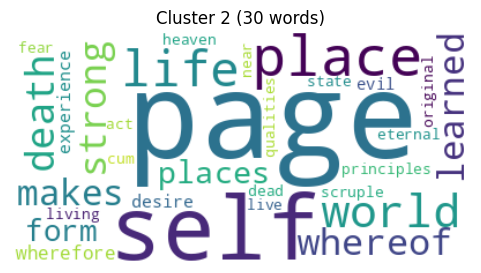

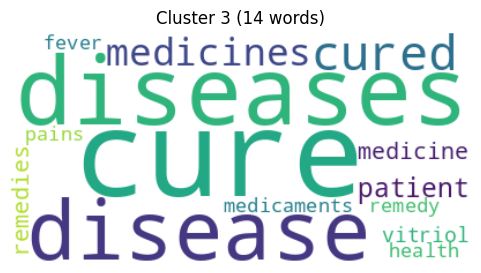

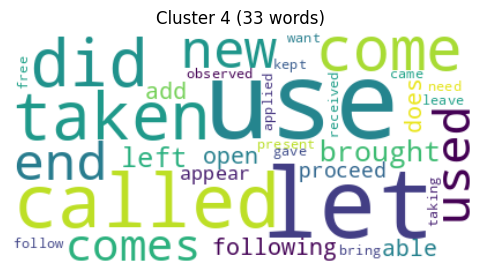

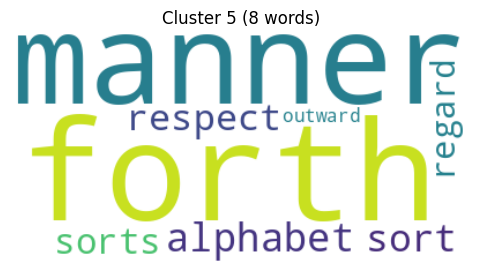

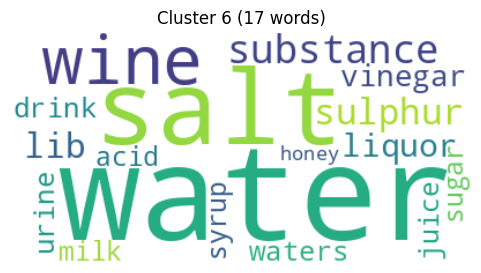

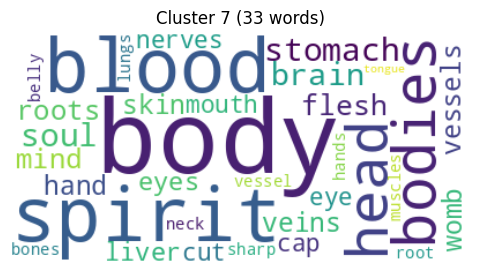

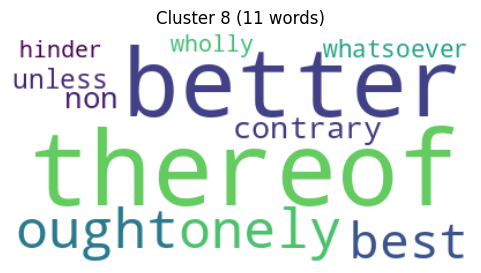

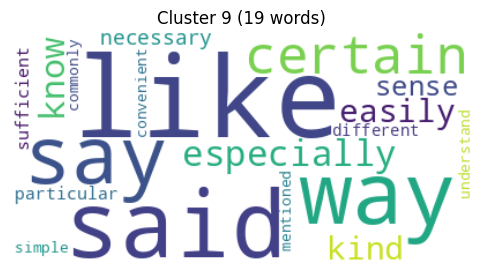

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import umap
import hdbscan
from sklearn.preprocessing import normalize

# Load your metadata
metadata_df = pd.read_csv("metadata.tsv", sep="\t")

# ===============================
# 1. Basic distributions
# ===============================
plt.figure(figsize=(6,4))
sns.histplot(metadata_df["freq"], bins=20, kde=True)
plt.title("Word frequency distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="cluster", data=metadata_df)
plt.title("Cluster distribution")
plt.show()

# Scatter of clusters vs frequency
plt.figure(figsize=(6,4))
sns.stripplot(x="cluster", y="freq", data=metadata_df, jitter=True)
plt.title("Cluster vs frequency")
plt.show()

# ===============================
# 2. Embeddings → UMAP + HDBSCAN
# ===============================
# Load embeddings if not already
import numpy as np
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = np.array(model.encode(metadata_df["word"].tolist(), normalize_embeddings=True))

# Dim reduction
umap_2d = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
U2 = umap_2d.fit_transform(embeddings)

# Clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=8, metric="euclidean")
labels = clusterer.fit_predict(U2)
metadata_df["hdbscan_cluster"] = labels

# Plot UMAP
plt.figure(figsize=(10,7))
sns.scatterplot(x=U2[:,0], y=U2[:,1], hue=labels, palette="tab10", s=20)
plt.title("HDBSCAN on UMAP (2D)")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

# ===============================
# 3. Word Clouds per Cluster
# ===============================
for c in sorted(set(labels)):
    if c == -1:  # skip noise
        continue
    words = metadata_df.loc[metadata_df["hdbscan_cluster"]==c, "word"]
    freqs = metadata_df.loc[metadata_df["hdbscan_cluster"]==c, "freq"]
    freq_dict = dict(zip(words, freqs))

    wc = WordCloud(width=400, height=200, background_color="white").generate_from_frequencies(freq_dict)
    plt.figure(figsize=(6,3))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Cluster {c} ({len(words)} words)")
    plt.show()


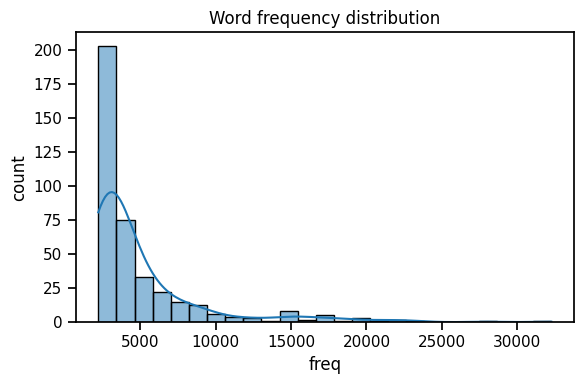

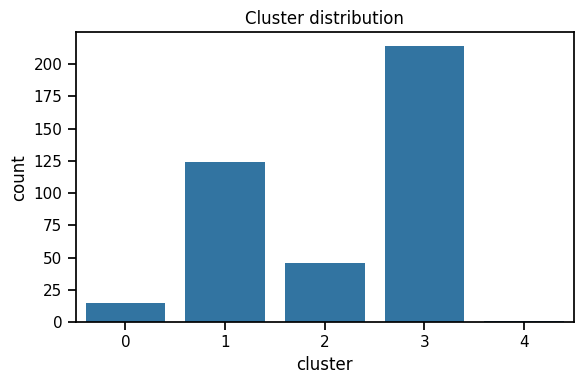

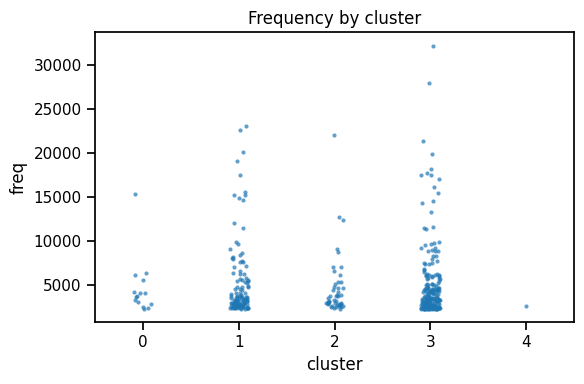

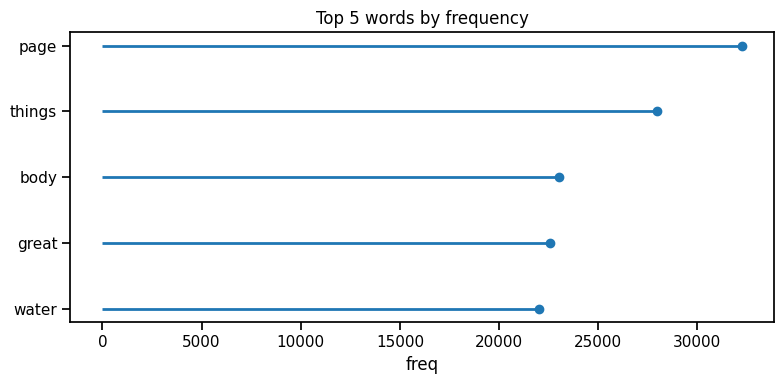

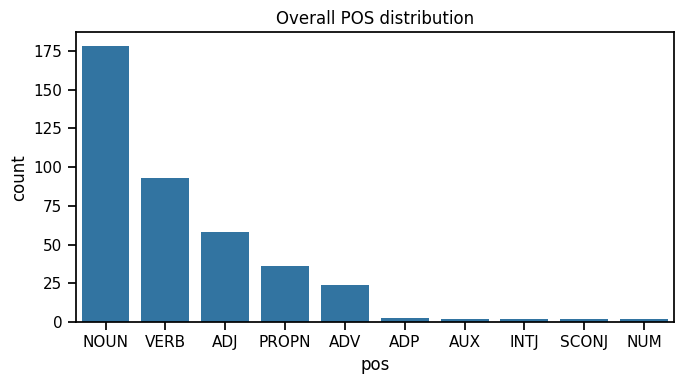

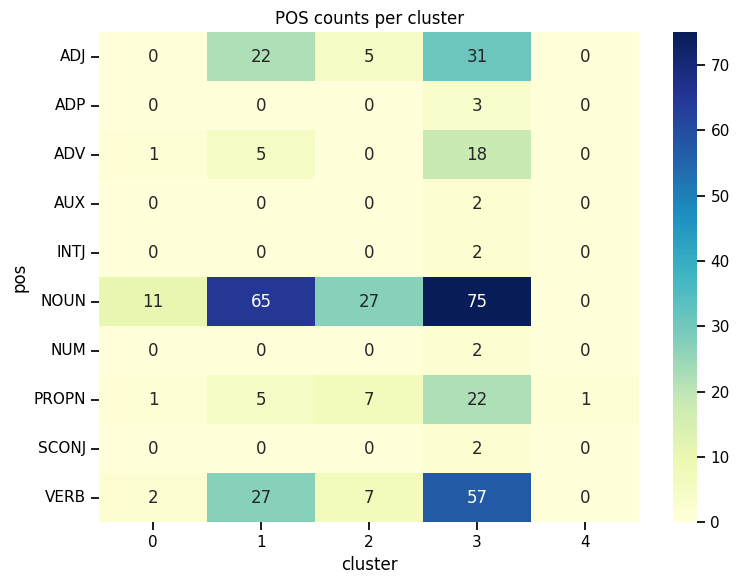

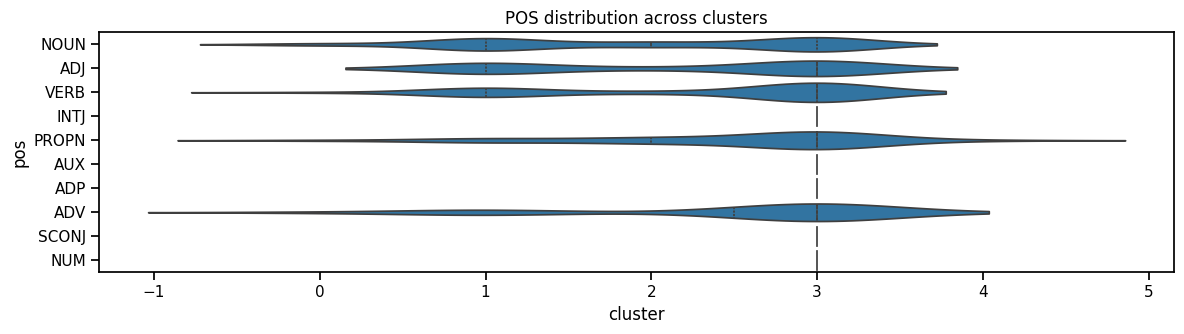

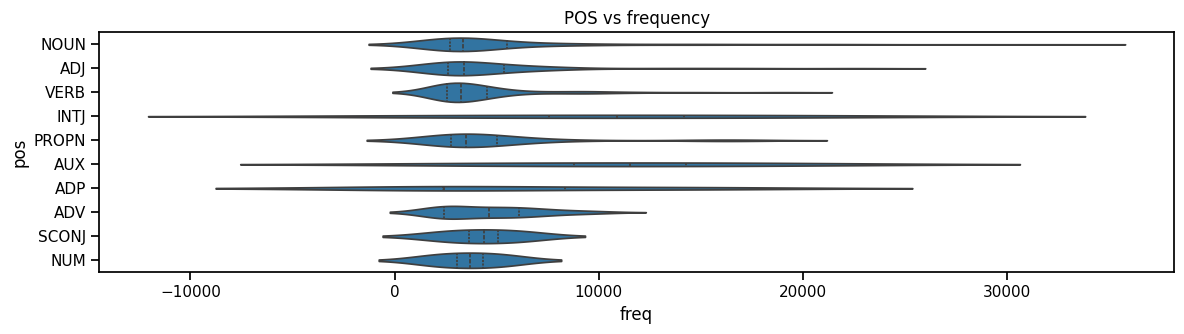

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


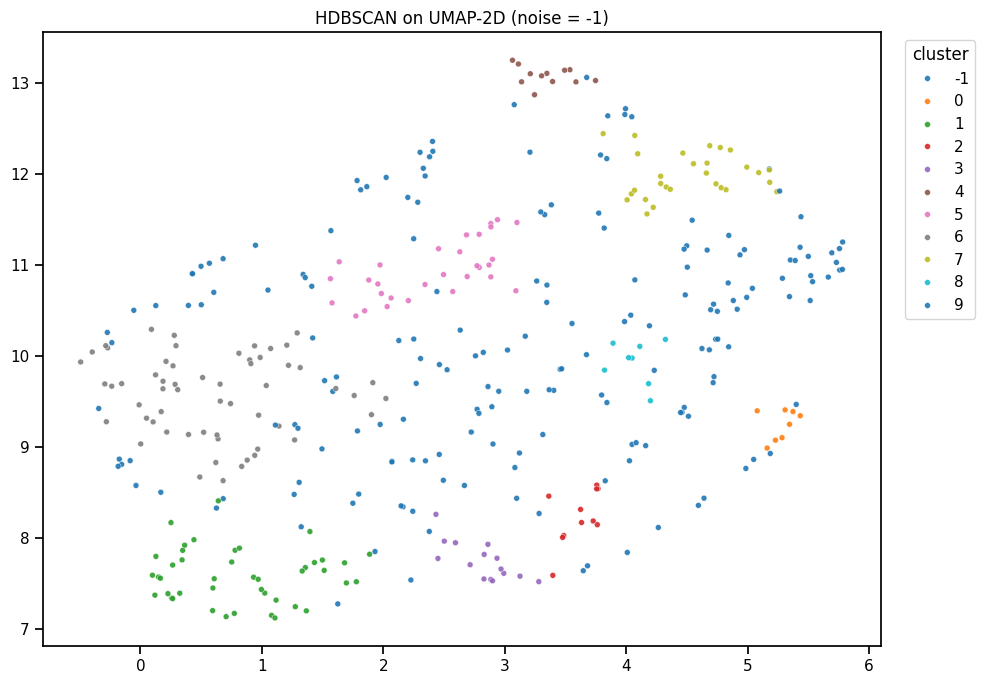

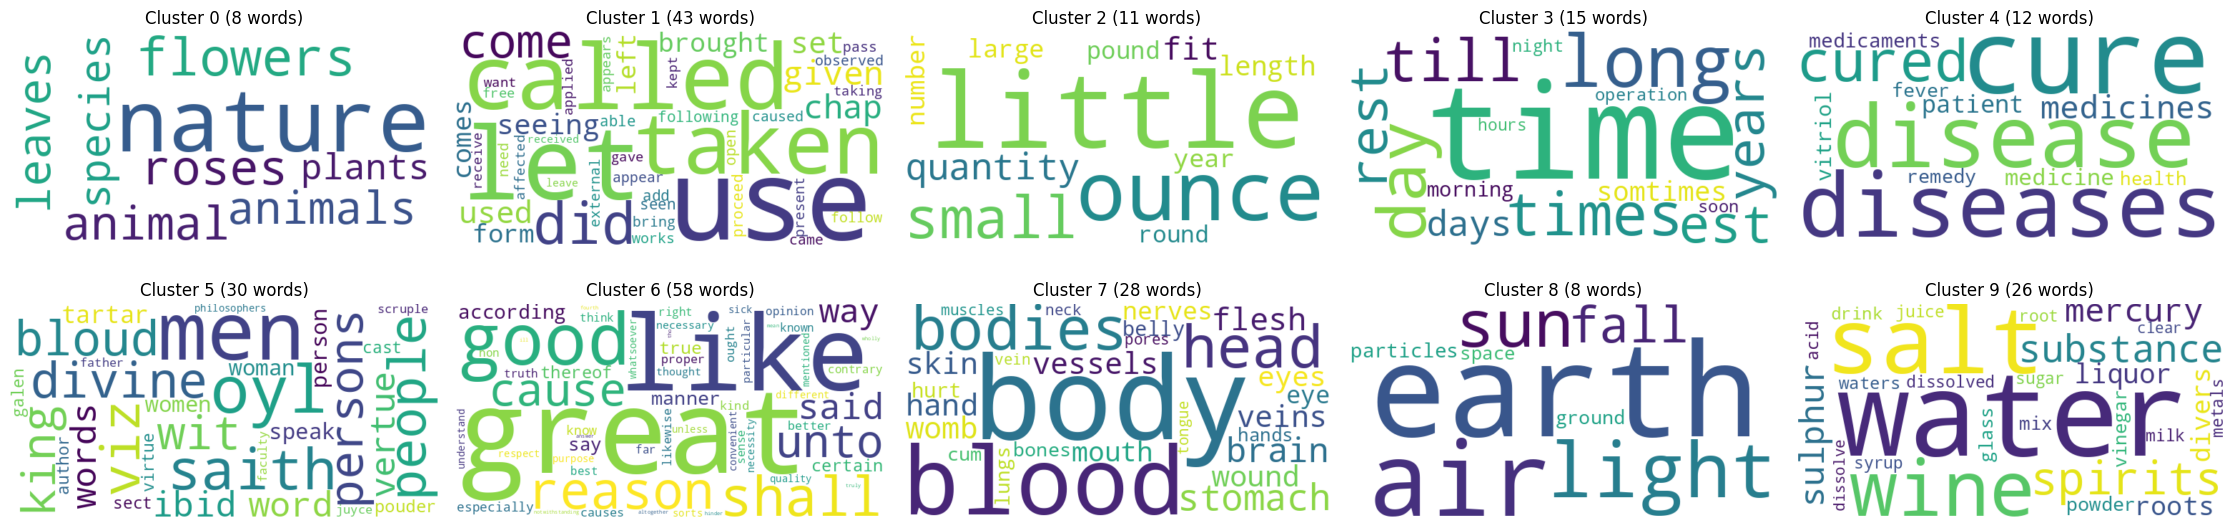

Chi-square (cluster × POS): p-value = 3.25807109890802e-14


In [ ]:
# =========================
# 0) Installs (quiet)
# =========================
!pip -q install sentence-transformers umap-learn hdbscan wordcloud spacy

# If you haven't downloaded the spaCy model before in this runtime, uncomment:
# !python -m spacy download en_core_web_sm

# =========================
# 1) Imports & load data
# =========================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
import umap, hdbscan
from wordcloud import WordCloud
import spacy, warnings
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_context("notebook")

# Load your metadata
metadata_df = pd.read_csv("metadata.tsv", sep="\t")
assert {"word","freq"}.issubset(metadata_df.columns), "metadata.tsv must have 'word' and 'freq' columns."

# Clean types
metadata_df["word"] = metadata_df["word"].astype(str)
metadata_df["freq"] = pd.to_numeric(metadata_df["freq"], errors="coerce")
metadata_df = metadata_df.dropna(subset=["freq"]).reset_index(drop=True)

# =========================
# 2) Descriptive plots
# =========================
plt.figure(figsize=(6,4))
sns.histplot(metadata_df["freq"], bins=25, kde=True)
plt.title("Word frequency distribution"); plt.xlabel("freq"); plt.ylabel("count"); plt.tight_layout(); plt.show()

if "cluster" in metadata_df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x="cluster", data=metadata_df)
    plt.title("Cluster distribution"); plt.tight_layout(); plt.show()

    plt.figure(figsize=(6,4))
    sns.stripplot(x="cluster", y="freq", data=metadata_df, jitter=True, size=3, alpha=0.7)
    plt.title("Frequency by cluster"); plt.tight_layout(); plt.show()

# Top 5 words lollipop (by freq)
topN = 5
top = metadata_df.nlargest(topN, "freq")[["word","freq"]].iloc[::-1]  # reverse for horizontal plot
plt.figure(figsize=(8,4))
plt.hlines(y=top["word"], xmin=0, xmax=top["freq"], linewidth=2)
plt.plot(top["freq"], top["word"], "o", ms=6)
plt.title(f"Top {topN} words by frequency"); plt.xlabel("freq"); plt.tight_layout(); plt.show()

# =========================
# 3) POS tagging & plots
# =========================
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    # If the runtime was fresh and model isn't installed yet:
    !python -m spacy download en_core_web_sm
    import importlib; importlib.invalidate_caches()
    nlp = spacy.load("en_core_web_sm")

# Add POS
metadata_df["pos"] = [nlp(w)[0].pos_ if len(nlp(w)) else "X" for w in metadata_df["word"]]

# POS bars
pos_counts = metadata_df["pos"].value_counts().sort_values(ascending=False)
plt.figure(figsize=(7,4))
sns.barplot(x=pos_counts.index, y=pos_counts.values)
plt.title("Overall POS distribution"); plt.ylabel("count"); plt.tight_layout(); plt.show()

# POS heatmap by cluster (if cluster exists)
if "cluster" in metadata_df.columns:
    pos_cluster = metadata_df.groupby(["pos","cluster"]).size().reset_index(name="count")
    pivot = pos_cluster.pivot(index="pos", columns="cluster", values="count").fillna(0)
    plt.figure(figsize=(8,6))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
    plt.title("POS counts per cluster"); plt.tight_layout(); plt.show()

    # Violin: POS vs cluster (shows where POS types concentrate)
    plt.figure(figsize=(12,3.5))
    sns.violinplot(data=metadata_df, x="cluster", y="pos", inner="quart")
    plt.title("POS distribution across clusters"); plt.tight_layout(); plt.show()

    # Violin: POS vs freq (how POS relate to frequency)
    plt.figure(figsize=(12,3.5))
    sns.violinplot(data=metadata_df, x="freq", y="pos", inner="quart")
    plt.title("POS vs frequency"); plt.tight_layout(); plt.show()

# =========================
# 4) Embeddings → UMAP + HDBSCAN + UMAP plot
# =========================
if "embeddings" in globals():
    E = np.asarray(embeddings, dtype=np.float32)
    if E.shape[0] != len(metadata_df):
        raise ValueError(f"`embeddings` rows {E.shape[0]} do not match metadata_df rows {len(metadata_df)}.")
else:
    model = SentenceTransformer("all-MiniLM-L6-v2")
    E = np.array(model.encode(metadata_df["word"].tolist(), normalize_embeddings=False), dtype=np.float32)

X = normalize(E)  # cosine geometry
Xp = PCA(n_components=0.90, svd_solver="full", random_state=42).fit_transform(X)

U2 = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric="cosine", random_state=42).fit_transform(Xp)

clusterer = hdbscan.HDBSCAN(min_cluster_size=8, metric="euclidean")
labels = clusterer.fit_predict(U2)
metadata_df["hdbscan"] = labels

plt.figure(figsize=(10,7))
sns.scatterplot(x=U2[:,0], y=U2[:,1], hue=labels, palette="tab10", s=18, alpha=0.9)
plt.title("HDBSCAN on UMAP-2D (noise = -1)"); plt.legend(bbox_to_anchor=(1.02,1), title="cluster"); plt.tight_layout(); plt.show()

# =========================
# 5) Word clouds per HDBSCAN cluster
# =========================
clusters = sorted(set(labels) - {-1})
if clusters:
    ncols = max(1, min(5, len(clusters)))
    nrows = int(np.ceil(len(clusters)/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3*nrows))
    if not isinstance(axes, np.ndarray): axes = np.array([axes])
    axes = axes.flatten()

    for ax, c in zip(axes, clusters):
        sub = metadata_df.loc[metadata_df["hdbscan"]==c, ["word","freq"]]
        freq_dict = dict(zip(sub["word"], sub["freq"]))
        if len(freq_dict) == 0:
            ax.axis("off"); continue
        wc = WordCloud(width=600, height=300, background_color="white").generate_from_frequencies(freq_dict)
        ax.imshow(wc, interpolation="bilinear"); ax.axis("off"); ax.set_title(f"Cluster {c} ({len(sub)} words)")
    # empty axes off
    for k in range(len(clusters), len(axes)): axes[k].axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No non-noise clusters found by HDBSCAN; skip word clouds.")

# =========================
# 6) (Optional) Chi-square: cluster × POS
# =========================
try:
    from scipy.stats import chi2_contingency
    df = metadata_df[metadata_df["hdbscan"]!=-1].copy()
    cont = pd.crosstab(df["hdbscan"].astype(str), df["pos"].astype(str))
    chi2, p, dof, _ = chi2_contingency(cont)
    print("Chi-square (cluster × POS): p-value =", p)
except Exception as e:
    print("Chi-square skipped:", e)


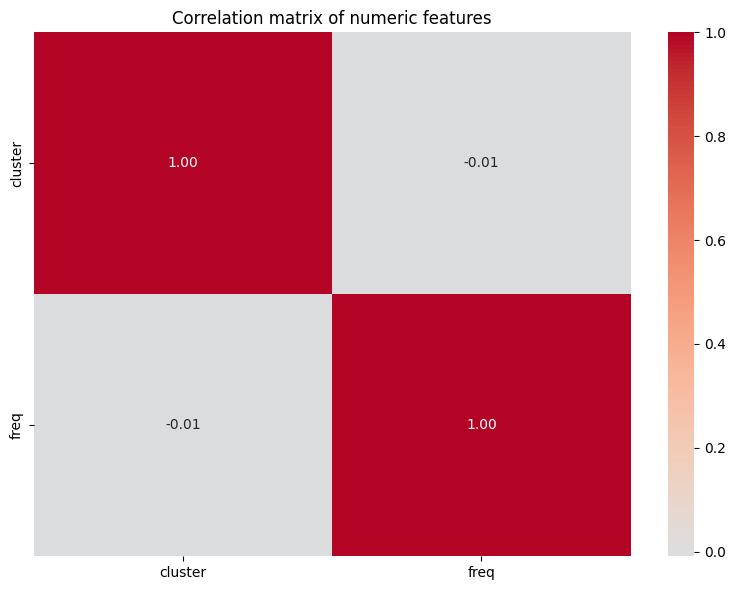

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Pick only numeric columns ---
num_df = metadata_df.select_dtypes(include=["int64", "float64"])

# --- Correlation matrix ---
corr = num_df.corr()

# --- Heatmap ---
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix of numeric features")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/hdbscan/plots.py:448: SyntaxWarning: invalid escape sequence '\l'
  axis.set_ylabel('$\lambda$ value')
/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


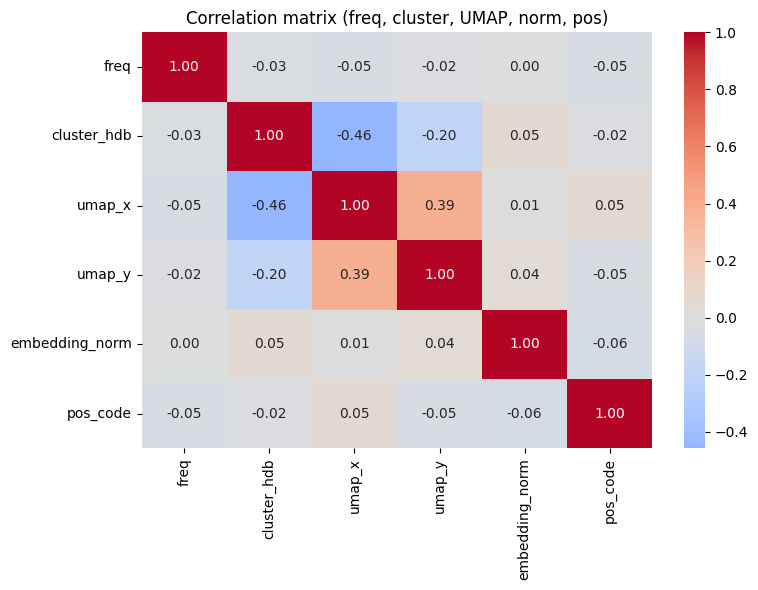

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==== Install dependencies if not already ====
!pip -q install sentence-transformers umap-learn hdbscan wordcloud spacy

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
import umap, hdbscan
from sentence_transformers import SentenceTransformer

# ==== Load metadata (word + freq at least) ====
metadata_df = pd.read_csv("metadata.tsv", sep="\t")

# ==== Embeddings ====
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = np.array(model.encode(metadata_df["word"].tolist(), normalize_embeddings=False), dtype=np.float32)

# ==== UMAP (for coordinates) ====
Xp = PCA(n_components=0.90, svd_solver="full", random_state=42).fit_transform(normalize(embeddings))
U2 = umap.UMAP(n_neighbors=20, min_dist=0.05, n_components=2,
               metric="cosine", random_state=42).fit_transform(Xp)

# ==== Clustering (HDBSCAN) ====
clusterer = hdbscan.HDBSCAN(min_cluster_size=8, metric="euclidean")
labels = clusterer.fit_predict(U2)
metadata_df["cluster_hdb"] = labels

# ==== Add numeric features ====
metadata_df["umap_x"] = U2[:,0]
metadata_df["umap_y"] = U2[:,1]
metadata_df["embedding_norm"] = np.linalg.norm(embeddings, axis=1)

# Encode POS (optional, requires spaCy)
import spacy
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    !python -m spacy download en_core_web_sm
    import importlib; importlib.invalidate_caches()
    nlp = spacy.load("en_core_web_sm")

metadata_df["pos"] = [nlp(w)[0].pos_ if len(nlp(w)) else "X" for w in metadata_df["word"]]
metadata_df["pos_code"] = LabelEncoder().fit_transform(metadata_df["pos"])

# ==== Correlation matrix ====
corr = metadata_df[["freq","cluster_hdb","umap_x","umap_y","embedding_norm","pos_code"]].corr()

# Save to CSV/Excel
corr.to_csv("correlation_matrix.csv")
corr.to_excel("correlation_matrix.xlsx")

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (freq, cluster, UMAP, norm, pos)")
plt.tight_layout()
plt.show()

# ==== Download from Colab ====
from google.colab import files
files.download("correlation_matrix.csv")   # or "correlation_matrix.xlsx"


In [ ]:
# =========================================
# Supervised learning on cluster labels
# =========================================
!pip -q install sentence-transformers scikit-learn joblib umap-learn

import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from joblib import dump

# ---------------------------
# 1) Get labels and features
# ---------------------------
# Choose the cluster column you actually have
label_cols = [c for c in ["cluster_hdb", "hdbscan", "cluster"] if c in metadata_df.columns]
if not label_cols:
    raise ValueError("No cluster label column found. Expected one of: 'cluster_hdb', 'hdbscan', 'cluster'.")
y_all = metadata_df[label_cols[0]].to_numpy()

# Exclude HDBSCAN noise if present
mask = (y_all != -1)
y = y_all[mask]

# Features: use existing embeddings; if missing, build them from words
if "embeddings" in globals():
    X_all = np.asarray(embeddings)
    if X_all.shape[0] != len(metadata_df):
        raise ValueError(f"embeddings rows ({X_all.shape[0]}) != metadata rows ({len(metadata_df)}).")
else:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("all-MiniLM-L6-v2")
    X_all = np.array(model.encode(metadata_df["word"].tolist(), normalize_embeddings=False), dtype=np.float32)

X = X_all[mask]

# Optional: use UMAP/PCA features instead of raw embeddings (comment out if not needed)
# import umap
# X = umap.UMAP(n_neighbors=20, min_dist=0.0, n_components=50,
#               metric="cosine", random_state=42).fit_transform(X)

# ---------------------------
# 2) Train / Test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ---------------------------
# 3) Two strong baselines
# ---------------------------
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),   # embeddings can be sparse-like; with_mean=False is safe
        ("clf", LogisticRegression(
            multi_class="multinomial", solver="lbfgs",
            max_iter=2000, n_jobs=-1, C=2.0, random_state=42))
    ]),
    "LinearSVM": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LinearSVC(C=1.0, random_state=42))
    ])
}

results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    results[name] = (acc, f1m, y_pred, pipe)

# Pick best by macro-F1
best_name = max(results, key=lambda k: results[k][1])
best_acc, best_f1, best_pred, best_model = results[best_name]

print(f"Best model: {best_name} | Acc: {best_acc:.3f} | Macro-F1: {best_f1:.3f}\n")
print("Classification report:")
print(classification_report(y_test, best_pred))
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, best_pred))

# ---------------------------
# 4) Save model for reuse
# ---------------------------
dump(best_model, "cluster_classifier.joblib")
print("Saved model -> cluster_classifier.joblib")

# ---------------------------
# 5) Predict on NEW words
# ---------------------------
def predict_clusters_for_words(words, model_name="all-MiniLM-L6-v2"):
    """Encode new words and predict cluster labels with the saved model."""
    from sentence_transformers import SentenceTransformer
    from joblib import load
    clf = load("cluster_classifier.joblib")
    enc = SentenceTransformer(model_name)
    Xnew = np.array(enc.encode(words, normalize_embeddings=False), dtype=np.float32)
    return clf.predict(Xnew)

# Example:
sample_words = ["artery", "wine", "flower", "cure", "king"]
try:
    preds = predict_clusters_for_words(sample_words)
    print("\nPredictions for new words:")
    for w, p in zip(sample_words, preds):
        print(f"  {w:>10s}  ->  cluster {p}")
except Exception as e:
    print("Prediction demo skipped:", e)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best model: LogReg | Acc: 0.900 | Macro-F1: 0.850

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.86      1.00      0.92         6
           2       1.00      0.40      0.57         5
           3       0.60      0.75      0.67         4
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00         5
           6       0.88      1.00      0.93         7
           7       0.80      1.00      0.89         4
           8       1.00      1.00      1.00        14

    accuracy                           0.90        50
   macro avg       0.90      0.85      0.85        50
weighted avg       0.92      0.90      0.89        50

Confusion matrix (rows=true, cols=pred):
[[ 3  0  0  0  0  0  0  0  0]
 [ 0  6  0  0  0  0  0  0  0]
 [ 0  0  2  2  0  0  0  1  0]
 [ 0  1  0  3  0  0  0  0  0]
 [ 0  0  0  0  1  0  1  0  0]
 [ 0  0  0  0  0  5  0  0  0]


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best model: LogReg | Acc=0.900 | Macro-F1=0.878 | Micro-F1=0.900

Classification report (best):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.86      1.00      0.92         6
           2       0.67      0.40      0.50         5
           3       0.60      0.75      0.67         4
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         5
           6       1.00      0.86      0.92         7
           7       0.80      1.00      0.89         4
           8       1.00      1.00      1.00        14

    accuracy                           0.90        50
   macro avg       0.88      0.89      0.88        50
weighted avg       0.90      0.90      0.89        50



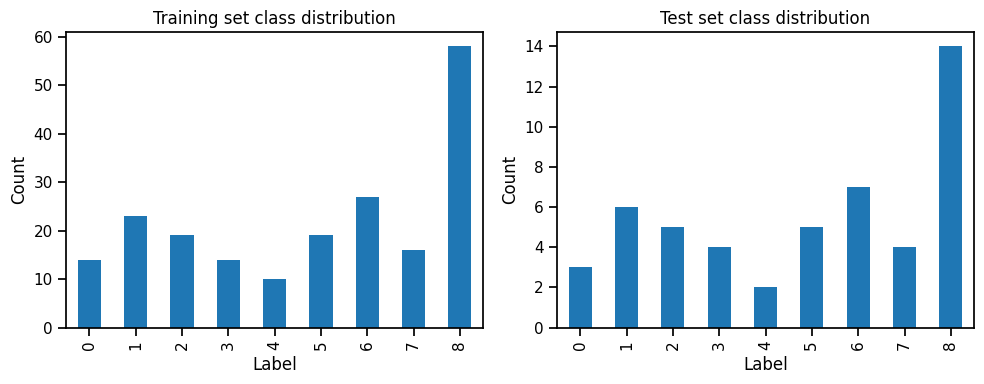

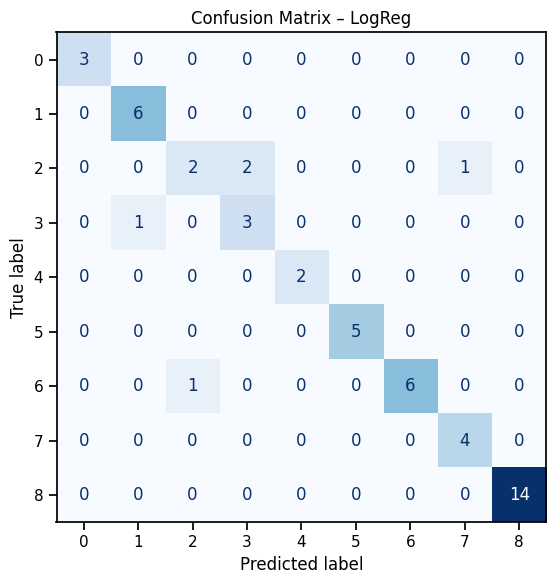

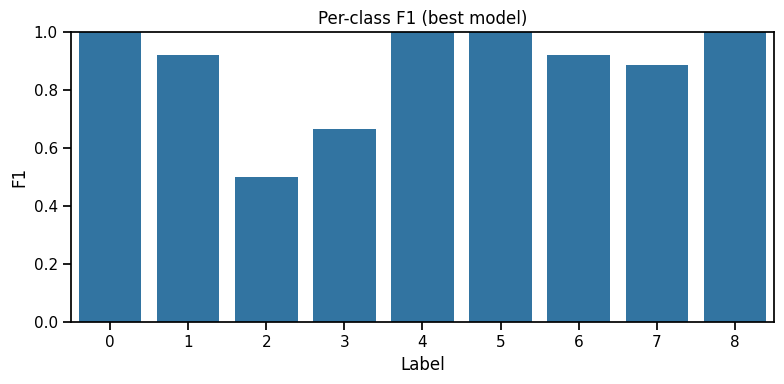

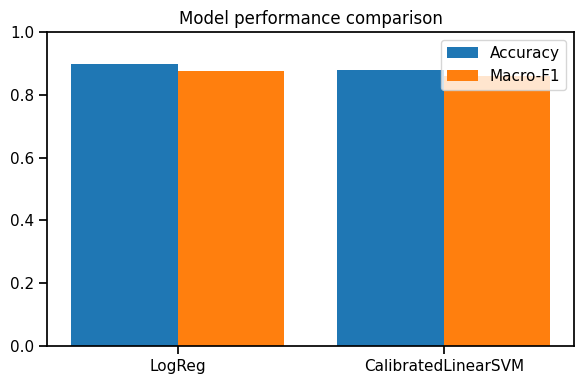

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


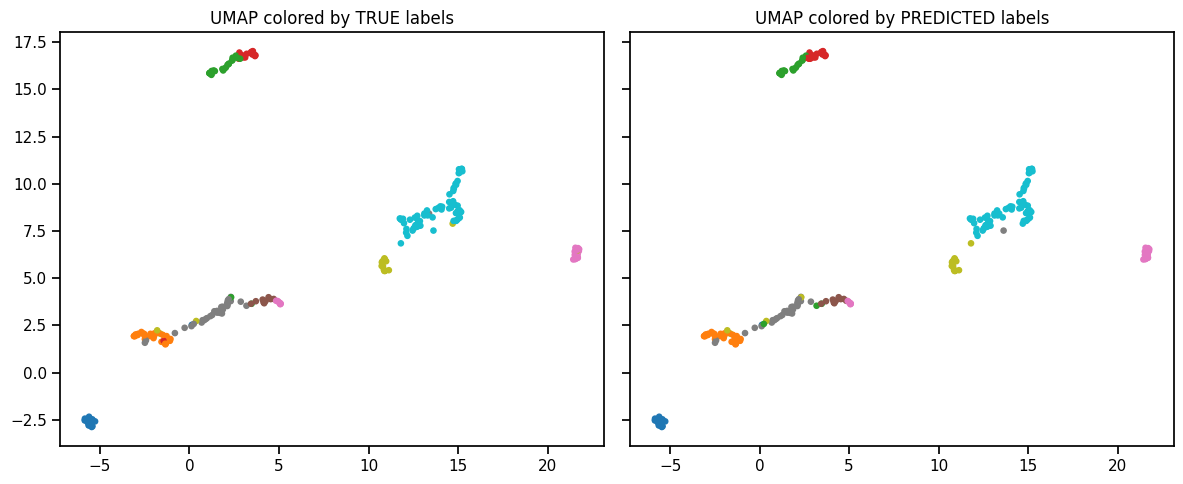

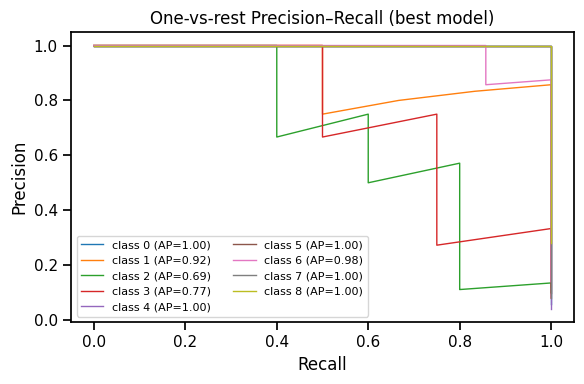

Mean Average Precision (macro): 0.929
Saved: cluster_classifier.joblib, label_map.csv
Prediction demo skipped: Cannot use scipy.linalg.eigh for sparse A with k >= N. Use scipy.linalg.eigh(A.toarray()) or reduce k.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:519: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  eigenvalues, eigenvectors = scipy.sparse.linalg.eigsh(


In [ ]:
# ================= Supervised Pipeline with Visuals =================
!pip -q install sentence-transformers scikit-learn joblib umap-learn matplotlib seaborn

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, average_precision_score)
from joblib import dump, load
import umap

sns.set_context("notebook")

# ------------------ 0) Locate labels column ------------------
label_cols = [c for c in ["cluster_hdb", "hdbscan", "cluster"] if c in metadata_df.columns]
if not label_cols:
    raise ValueError("No cluster-label column found. Add one of: 'cluster_hdb', 'hdbscan', or 'cluster'.")
y_all = metadata_df[label_cols[0]].to_numpy()

# Drop noise if present
mask = (y_all != -1)
X_words = metadata_df.loc[mask, "word"].tolist()
y = y_all[mask]

# ------------------ 1) Features (embeddings) ------------------
if "embeddings" in globals():
    E_all = np.asarray(embeddings)
    if E_all.shape[0] != len(metadata_df):
        raise ValueError(f"embeddings rows ({E_all.shape[0]}) != metadata rows ({len(metadata_df)}).")
    X = E_all[mask]
else:
    from sentence_transformers import SentenceTransformer
    enc = SentenceTransformer("all-MiniLM-L6-v2")
    X = np.array(enc.encode(X_words, normalize_embeddings=False), dtype=np.float32)

# Optional: UMAP to 50D to denoise (often helps linear models)
X_umap = umap.UMAP(n_neighbors=20, min_dist=0.0, n_components=50,
                   metric="cosine", random_state=42).fit_transform(X)

# ------------------ 2) Train/Test split ------------------
X_train, X_test, y_train, y_test, words_train, words_test = train_test_split(
    X_umap, y, X_words, test_size=0.2, random_state=42, stratify=y
)

# ------------------ 3) Models ------------------
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(
            multi_class="multinomial", solver="lbfgs",
            class_weight="balanced", max_iter=2000, n_jobs=-1, C=2.0, random_state=42))
    ]),
    "CalibratedLinearSVM": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", CalibratedClassifierCV(
            estimator=LinearSVC(C=1.0, class_weight="balanced", random_state=42),
            method="sigmoid", cv=3))
    ])
}


results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # metrics
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_micro = f1_score(y_test, y_pred, average="micro")
    results[name] = {"acc": acc, "f1_macro": f1_macro, "f1_micro": f1_micro,
                     "y_pred": y_pred, "model": pipe}

# pick best by macro-F1
best_name = max(results, key=lambda k: results[k]["f1_macro"])
best = results[best_name]
best_model = best["model"]
print(f"Best model: {best_name} | Acc={best['acc']:.3f} | Macro-F1={best['f1_macro']:.3f} | Micro-F1={best['f1_micro']:.3f}\n")
print("Classification report (best):\n", classification_report(y_test, best["y_pred"]))

# ------------------ 4) Plots ------------------
# (A) Class distribution (train & test)
fig, axes = plt.subplots(1, 2, figsize=(10,4))
pd.Series(y_train).value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Training set class distribution"); axes[0].set_xlabel("Label"); axes[0].set_ylabel("Count")
pd.Series(y_test).value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Test set class distribution"); axes[1].set_xlabel("Label"); axes[1].set_ylabel("Count")
plt.tight_layout(); plt.show()

# (B) Confusion matrix (best model)
fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay.from_predictions(y_test, best["y_pred"], ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix – {best_name}"); plt.tight_layout(); plt.show()

# (C) Per-class F1 bars
from sklearn.metrics import f1_score
f1_per_class = f1_score(y_test, best["y_pred"], average=None)
labels_sorted = sorted(np.unique(y_test))
plt.figure(figsize=(8,4))
sns.barplot(x=[str(l) for l in labels_sorted], y=f1_per_class)
plt.ylim(0,1); plt.title("Per-class F1 (best model)"); plt.xlabel("Label"); plt.ylabel("F1")
plt.tight_layout(); plt.show()

# (D) Model comparison
plt.figure(figsize=(6,4))
names = list(results.keys())
accs = [results[n]["acc"] for n in names]
f1s  = [results[n]["f1_macro"] for n in names]
x = np.arange(len(names))
plt.bar(x - 0.2, accs, width=0.4, label="Accuracy")
plt.bar(x + 0.2, f1s,  width=0.4, label="Macro-F1")
plt.xticks(x, names); plt.ylim(0,1); plt.legend(); plt.title("Model performance comparison")
plt.tight_layout(); plt.show()

# (E) UMAP(2D) scatter: TRUE vs PREDICTED (best model)
U2_all = umap.UMAP(n_neighbors=20, min_dist=0.1, n_components=2,
                   metric="cosine", random_state=42).fit_transform(np.vstack([X_train, X_test]))
y_all_vis = np.hstack([y_train, y_test])
pred_all = np.hstack([best_model.predict(X_train), best_model.predict(X_test)])

fig, axes = plt.subplots(1,2, figsize=(12,5), sharex=True, sharey=True)
sc0 = axes[0].scatter(U2_all[:,0], U2_all[:,1], c=y_all_vis, s=14, cmap="tab10")
axes[0].set_title("UMAP colored by TRUE labels")
sc1 = axes[1].scatter(U2_all[:,0], U2_all[:,1], c=pred_all, s=14, cmap="tab10")
axes[1].set_title("UMAP colored by PREDICTED labels")
plt.tight_layout(); plt.show()

# (F) Macro Precision-Recall curve (best model; needs predict_proba)
try:
    # not all models expose predict_proba; Calibrated SVM and LogReg do
    probs = best_model.predict_proba(X_test)
    # binarize labels for macro-PR
    from sklearn.preprocessing import label_binarize
    classes = np.unique(y)
    Yb = label_binarize(y_test, classes=classes)
    ap_scores = []
    plt.figure(figsize=(6,4))
    for k, cls in enumerate(classes):
        precision, recall, _ = precision_recall_curve(Yb[:,k], probs[:,k])
        ap = average_precision_score(Yb[:,k], probs[:,k])
        ap_scores.append(ap)
        plt.plot(recall, precision, lw=1, label=f"class {cls} (AP={ap:.2f})")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("One-vs-rest Precision–Recall (best model)")
    plt.legend(ncol=2, fontsize=8); plt.tight_layout(); plt.show()
    print(f"Mean Average Precision (macro): {np.mean(ap_scores):.3f}")
except Exception as e:
    print("PR curve skipped (model has no predict_proba):", e)

# ------------------ 5) Save best model + label map ------------------
label_map = {int(k): int(k) for k in np.unique(y)}  # replace with {id: "name"} if you have human names
dump(best_model, "cluster_classifier.joblib")
pd.Series(label_map).to_csv("label_map.csv", header=["name"])
print("Saved: cluster_classifier.joblib, label_map.csv")

# ------------------ 6) Predict on new words ------------------
def predict_clusters_for_words(words, model_name="all-MiniLM-L6-v2"):
    enc_local = enc if "enc" in globals() else __import__("sentence_transformers").SentenceTransformer(model_name)
    Xnew = np.array(enc_local.encode(words, normalize_embeddings=False), dtype=np.float32)
    Xnew_umap = umap.UMAP(n_neighbors=20, min_dist=0.0, n_components=50,
                          metric="cosine", random_state=42).fit_transform(Xnew)
    clf = load("cluster_classifier.joblib")
    return clf.predict(Xnew_umap)

demo = ["artery", "wine", "flower", "cure", "king"]
try:
    preds = predict_clusters_for_words(demo)
    print("Demo predictions:")
    for w,p in zip(demo, preds):
        print(f"  {w:>10s} -> cluster {p}")
except Exception as e:
    print("Prediction demo skipped:", e)


In [ ]:
# ===== Compare RAW vs PCA vs UMAP features for supervised classification =====
!pip -q install sentence-transformers scikit-learn joblib umap-learn

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, average_precision_score)
import umap
sns.set_context("notebook")

# ---------- 0) Labels & embeddings ----------
label_cols = [c for c in ["cluster_hdb", "hdbscan", "cluster"] if c in metadata_df.columns]
assert label_cols, "No cluster label column found in metadata_df."
y_all = metadata_df[label_cols[0]].to_numpy()
mask = (y_all != -1)
y = y_all[mask]
words = metadata_df.loc[mask, "word"].tolist()

if "embeddings" in globals():
    E_all = np.asarray(embeddings)
    assert E_all.shape[0] == len(metadata_df), "embeddings rows != metadata_df rows"
    E = E_all[mask].astype(np.float32)
else:
    from sentence_transformers import SentenceTransformer
    enc = SentenceTransformer("all-MiniLM-L6-v2")
    E = np.array(enc.encode(words, normalize_embeddings=False), dtype=np.float32)

# ---------- 1) Build 3 feature variants ----------
def build_variants(E):
    feats = {}
    feats["RAW"] = E
    Xp = PCA(n_components=0.90, svd_solver="full", random_state=42).fit_transform(E / (np.linalg.norm(E,axis=1,keepdims=True)+1e-9))
    feats["PCA90"] = Xp
    Xu = umap.UMAP(n_neighbors=20, min_dist=0.0, n_components=50,
                   metric="cosine", random_state=42).fit_transform(E)
    feats["UMAP50"] = Xu
    return feats

feats = build_variants(E)

# ---------- 2) Train/eval helper ----------
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

def train_eval(X, y, n_splits=5, random_state=42):
    y = np.asarray(y)

    # fallback: use KFold if Stratified fails
    unique, counts = np.unique(y, return_counts=True)
    if np.min(counts) < 2:
        cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    else:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    accs, f1s = [], []
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        clf = LogisticRegression(max_iter=200)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        accs.append(accuracy_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred, average="macro"))

    return {"acc": np.mean(accs), "f1_macro": np.mean(f1s)}



# ---------- 3) Summary table & bar plot ----------
rows = []
for vname, res in all_results.items():
    for mname, r in res.items():
        rows.append({"features": vname, "model": mname, "accuracy": r["acc"], "macro_f1": r["f1_macro"]})
summary = pd.DataFrame(rows).sort_values(["macro_f1","accuracy"], ascending=False)
print(summary)

plt.figure(figsize=(8,4))
for i,(vname, grp) in enumerate(summary.groupby("features")):
    plt.bar(np.arange(len(grp))+i*0.3, grp["macro_f1"], width=0.28, label=f"{vname} (F1)")
plt.xticks(np.arange(len(grp))+0.3, grp["model"])
plt.ylim(0,1); plt.title("Macro-F1 by model & feature variant"); plt.legend(); plt.tight_layout(); plt.show()

# ---------- 4) Pick best combo and visualize in detail ----------
best_feats = best_row["features"]
best_model_name = best_row["model"]
best = all_results[best_feats][best_model_name]

print(
    f"\nBest: {best_model_name} on {best_feats}  |  "
    f"Acc={best.get('acc', best.get('accuracy', float('nan'))):.3f}  "
    f"Macro-F1={best.get('f1_macro', best.get('macro_f1', float('nan'))):.3f}"
)
print("\nClassification report:\n", classification_report(best["y_test"], best["y_pred"]))


# Confusion matrix
fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay.from_predictions(best["y_test"], best["y_pred"], ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix – {best_model_name} ({best_feats})"); plt.tight_layout(); plt.show()

# One-vs-rest PR curves (needs predict_proba)
try:
    probs = all_results[best_feats][best_model_name]["model"].predict_proba(best["X_test"])
    classes = np.unique(y)
    from sklearn.preprocessing import label_binarize
    Yb = label_binarize(best["y_test"], classes=classes)
    aps = []
    plt.figure(figsize=(7,4))
    for k, cls in enumerate(classes):
        P, R, _ = precision_recall_curve(Yb[:,k], probs[:,k])
        ap = average_precision_score(Yb[:,k], probs[:,k]); aps.append(ap)
        plt.plot(R, P, lw=1, label=f"class {cls} (AP={ap:.2f})")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"One-vs-rest PR – {best_model_name} ({best_feats})")
    plt.legend(ncol=2, fontsize=8); plt.tight_layout(); plt.show()
    print(f"Mean Average Precision (macro): {np.mean(aps):.3f}")
except Exception as e:
    print("PR curves skipped (model lacks predict_proba):", e)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyError: 'macro_f1'

⚠️ Fold failed: ValueError: Requesting 3-fold cross-validation but provided less than 3 examples for at least one class.
⚠️ Fold failed: ValueError: Requesting 3-fold cross-validation but provided less than 3 examples for at least one class.
⚠️ Fold failed: ValueError: Requesting 3-fold cross-validation but provided less than 3 examples for at least one class.
⚠️ Fold failed: ValueError: Requesting 3-fold cross-validation but provided less than 3 examples for at least one class.
⚠️ Fold failed: ValueError: Requesting 3-fold cross-validation but provided less than 3 examples for at least one class.
⚠️ Fold failed: ValueError: Requesting 3-fold cross-validation but provided less than 3 examples for at least one class.
⚠️ Fold failed: ValueError: Requesting 3-fold cross-validation but provided less than 3 examples for at least one class.
⚠️ Fold failed: ValueError: Requesting 3-fold cross-validation but provided less than 3 examples for at least one class.
⚠️ Fold failed: ValueError: Requ

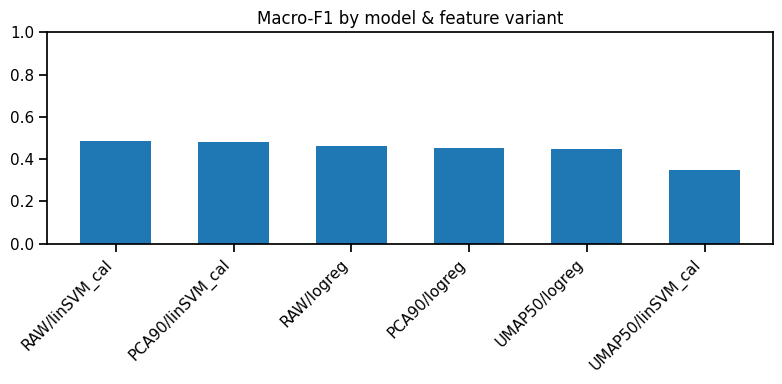

ValueError: Requesting 3-fold cross-validation but provided less than 3 examples for at least one class.

In [ ]:
# ---------- 2) Robust CV helpers ----------
import numpy as np, pandas as pd
from collections import Counter
from sklearn.model_selection import StratifiedKFold, KFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def make_cv(y, n_splits=5, random_state=42):
    y = np.asarray(y)
    counts = Counter(y)
    if len(counts) < 2 or min(counts.values()) < 2:
        # too few per class for stratification -> fallback
        n_splits = min(n_splits, max(2, len(y)))
        return KFold(n_splits=n_splits, shuffle=True, random_state=random_state), False
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state), True

def train_eval_cv(X, y, model, n_splits=5, random_state=42):
    """Always returns dict with 'acc' and 'f1_macro' (NaN if a fold fails)."""
    X = np.asarray(X); y = np.asarray(y)
    cv, _ = make_cv(y, n_splits=n_splits, random_state=random_state)
    accs, f1s = [], []
    for tr, te in cv.split(X, y):
        Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
        try:
            model.fit(Xtr, ytr)
            ypred = model.predict(Xte)
            accs.append(accuracy_score(yte, ypred))
            f1s.append(f1_score(yte, ypred, average="macro", zero_division=0))
        except Exception as e:
            accs.append(np.nan); f1s.append(np.nan)
            print(f"⚠️ Fold failed: {type(e).__name__}: {e}")
    return {"acc": float(np.nanmean(accs)), "f1_macro": float(np.nanmean(f1s))}

# Models to compare
models = {
    "logreg": LogisticRegression(max_iter=1000, n_jobs=None),
    "linSVM_cal": CalibratedClassifierCV(LinearSVC(), method="sigmoid", cv=3),  # gives predict_proba
}

# ---------- 3) Run CV over features & models; build summary ----------
all_results = {}
for feat_name, X in feats.items():
    res = {}
    for model_name, model in models.items():
        res[model_name] = train_eval_cv(X, y, model=model, n_splits=5, random_state=42)
    all_results[feat_name] = res

rows = []
for vname, res in all_results.items():
    for mname, r in res.items():
        rows.append({
            "features": vname,
            "model": mname,
            "accuracy": r.get("acc", np.nan),
            "macro_f1": r.get("f1_macro", np.nan),
        })
summary = pd.DataFrame(rows).sort_values(["macro_f1","accuracy"], ascending=False, na_position="last").reset_index(drop=True)
print(summary)

# Bar plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
xpos = np.arange(len(summary))
plt.bar(xpos, summary["macro_f1"], width=0.6)
plt.xticks(xpos, [f'{f}/{m}' for f,m in zip(summary["features"], summary["model"])], rotation=45, ha="right")
plt.ylim(0,1); plt.title("Macro-F1 by model & feature variant"); plt.tight_layout(); plt.show()

# ---------- 4) Pick best combo; detailed train/test, report & PR curves ----------
best_row = summary.iloc[0]
best_feats = best_row["features"]
best_model_name = best_row["model"]
best_model = models[best_model_name]
Xbest = feats[best_feats]

# stratified split if possible
cv, strat_ok = make_cv(y, n_splits=5, random_state=42)
stratify_arg = y if strat_ok else None
Xtr, Xte, ytr, yte = train_test_split(Xbest, y, test_size=0.2, random_state=42, stratify=stratify_arg)

best_model.fit(Xtr, ytr)
yp = best_model.predict(Xte)

print(
    f"\nBest: {best_model_name} on {best_feats}  |  "
    f"Acc={accuracy_score(yte, yp):.3f}  Macro-F1={f1_score(yte, yp, average='macro', zero_division=0)::.3f}"
)
print("\nClassification report:\n", classification_report(yte, yp, zero_division=0))

from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay.from_predictions(yte, yp, ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix – {best_model_name} ({best_feats})"); plt.tight_layout(); plt.show()

# PR curves (if predict_proba available)
try:
    import numpy as np
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import precision_recall_curve, average_precision_score

    if hasattr(best_model, "predict_proba"):
        prob = best_model.predict_proba(Xte)
        classes = np.unique(y)
        Yb = label_binarize(yte, classes=classes)
        aps = []
        plt.figure(figsize=(7,4))
        for k, cls in enumerate(classes):
            P, R, _ = precision_recall_curve(Yb[:,k], prob[:,k])
            ap = average_precision_score(Yb[:,k], prob[:,k]); aps.append(ap)
            plt.plot(R, P, lw=1, label=f"class {cls} (AP={ap:.2f})")
        plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"One-vs-rest PR – {best_model_name} ({best_feats})")
        plt.legend(ncol=2, fontsize=8); plt.tight_layout(); plt.show()
        print(f"Mean Average Precision (macro): {np.mean(aps):.3f}")
    else:
        print("PR curves skipped: selected model has no predict_proba.")
except Exception as e:
    print("PR curves skipped:", e)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="cluster", y="count", data=metadata_df)
plt.title("Distribution of counts per cluster")
plt.show()


NameError: name 'metadata_df' is not defined

In [ ]:
cluster_col = "hdbscan_label"          # or "spherical_kmeans_label"
tag_col     = "category"                # <-- change to your real tag column

# sanity checks
assert cluster_col in metadata_df.columns, f"Missing column: {cluster_col}"
assert tag_col in metadata_df.columns, f"Missing column: {tag_col}"

# drop rows with missing labels/tags
df = metadata_df[[cluster_col, tag_col]].dropna()

# optional: cast to str to avoid issues
df[cluster_col] = df[cluster_col].astype(str)
df[tag_col]     = df[tag_col].astype(str)

# contingency + chi-square
cont = pd.crosstab(df[cluster_col], df[tag_col])
from scipy.stats import chi2_contingency
chi2, p, dof, exp = chi2_contingency(cont)
print("Chi-square p-value:", p)
cont


In [ ]:
!pip -q install spacy
!python -m spacy download en_core_web_sm

import spacy
nlp = spacy.load("en_core_web_sm")

def pos_tag_word(w):
    doc = nlp(w)
    return doc[0].pos_ if len(doc) else "X"

metadata_df["tag"] = metadata_df["word"].astype(str).apply(pos_tag_word)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 22.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Suppose you have cosine matrices S_w2v and S_gpt2 on the SAME word list
tri = np.triu_indices_from(S, k=1)
diff = (S_w2v - S_gpt2)[tri]
from scipy import stats
print("Paired t-test:", stats.ttest_1samp(diff, 0.0))
print("Wilcoxon:", stats.wilcoxon(diff))


NameError: name 'S_w2v' is not defined

In [ ]:
K = 10
pred = []
for i in range(len(embeddings)):
    idx = np.argsort(D[i])[:K]
    maj = np.bincount(labels[idx]).argmax()
    pred.append(maj == labels[i])
print("kNN consistency:", np.mean(pred))


kNN consistency: 0.825


In [ ]:
from sklearn.metrics import adjusted_rand_score
def kmeans_labels(seed):
    return KMeans(n_clusters=K, random_state=seed, n_init=10).fit_predict(embeddings)
L1, L2 = kmeans_labels(1), kmeans_labels(2)
print("ARI between runs:", adjusted_rand_score(L1, L2))


ARI between runs: 0.26016728277445983


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# X = your embeddings
X = embeddings  # shape: (n_words, dim)

# y = numeric target
metadata_df["word_length"] = metadata_df["word"].apply(len)
y = metadata_df["word_length"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))


R²: -6.981122970581055


TypeError: got an unexpected keyword argument 'squared'

In [ ]:
!pip install pymc arviz

import pymc as pm
import numpy as np
import pandas as pd

# X = embeddings (n_words x dim)
# y = log_freq (example target)
X = np.asarray(embeddings)
y = np.log1p([w2v.wv.get_vecattr(w, "count") for w in selected_words])

# Take just first 10 dimensions for speed
X_small = X[:, :10]

with pm.Model() as model:
    beta = pm.Normal("beta", mu=0, sigma=1, shape=X_small.shape[1])
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    mu = alpha + pm.math.dot(X_small, beta)
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    trace = pm.sample(1000, tune=1000, target_accept=0.9)

pm.summary(trace)


Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,8.315,0.061,8.206,8.430,0.001,0.001,1933.0,1246.0,1.0
beta[0],0.087,0.130,-0.158,0.320,0.003,0.003,2656.0,1343.0,1.0
beta[1],0.102,0.131,-0.147,0.337,0.003,0.004,2441.0,1293.0,1.0
beta[2],-0.076,0.130,-0.336,0.151,0.002,0.003,2823.0,1259.0,1.0
beta[3],0.003,0.132,-0.237,0.250,0.003,0.003,2379.0,1568.0,1.0
beta[4],-0.091,0.132,-0.325,0.167,0.003,0.003,2675.0,1518.0,1.0
beta[5],0.129,0.132,-0.124,0.367,0.003,0.003,2406.0,1659.0,1.0
beta[6],-0.159,0.135,-0.415,0.090,0.002,0.003,2974.0,1361.0,1.0
beta[7],0.126,0.134,-0.120,0.381,0.003,0.003,2760.0,1578.0,1.0
beta[8],-0.008,0.125,-0.241,0.225,0.002,0.003,2737.0,1513.0,1.0


from matplotlib import pyplot as plt
_df_0['mean'].plot(kind='hist', bins=20, title='mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['sd'].plot(kind='hist', bins=20, title='sd')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['hdi_3%'].plot(kind='hist', bins=20, title='hdi_3%')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['r_hat']
  ys = series['hdi_97%']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('r_hat', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('r_hat')
_ = plt.ylabel('hdi_97%')

from matplotlib import pyplot as plt
_df_12['mean'].plot(kind='line', figsize=(8, 4), title='mean')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['sd'].plot(kind='line', figsize=(8, 4), title='sd')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['hdi_3%'].plot(kind='line', figsize=(8, 4), title='hdi_3%')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['hdi_97%'].plot(kind='line', figsize=(8, 4), title='hdi_97%')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
!pip install pymc arviz

import pymc as pm
import numpy as np
import pandas as pd

# X = embeddings (n_words x dim)
# y = log_freq (example target)
X = np.asarray(embeddings)
y = np.log1p([w2v.wv.get_vecattr(w, "count") for w in selected_words])

# Take just first 10 dimensions for speed
X_small = X[:, :10]

with pm.Model() as model:
    beta = pm.Normal("beta", mu=0, sigma=1, shape=X_small.shape[1])
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    mu = alpha + pm.math.dot(X_small, beta)
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    trace = pm.sample(1000, tune=1000, target_accept=0.9)

pm.summary(trace)

NameError: name 'embeddings' is not defined

In [ ]:
!pip install gensim


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 13.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
opencv-python 4

In [ ]:
from gensim.models import Word2Vec
import re


In [ ]:
from gensim.models import Word2Vec
import re

# Assuming you already have your text data in df["chunk_text"] or similar
def tokenize_line(text: str):
    tokens = re.findall(r"[a-z]+", text.lower())
    return [t for t in tokens if len(t) >= 3]

sentences = [tokenize_line(t) for t in df["chunk_text"].astype(str)]

# Train Word2Vec
w2v = Word2Vec(
    sentences,
    vector_size=300,
    window=5,
    min_count=3,
    workers=4,
    sg=1,
    epochs=10
)

# Vocabulary
vocab_words = list(w2v.wv.key_to_index.keys())

# Take top-K frequent words
TOP_K_WORDS = 400
selected_words = vocab_words[: min(TOP_K_WORDS, len(vocab_words))]
print(f"Selected {len(selected_words)} words from the trained vocabulary.")

# Embeddings for these words
embeddings = np.vstack([w2v.wv[w] for w in selected_words])


NameError: name 'df' is not defined

In [ ]:
# Take the top-K frequent words
selected_words = vocab_words[: min(TOP_K_WORDS, len(vocab_words))]
print(f"Selected {len(selected_words)} words from the trained vocabulary.")


NameError: name 'vocab_words' is not defined

In [ ]:
import pymc as pm
import arviz as az
import numpy as np

# make sure y is defined BEFORE this cell
y = np.log1p([w2v.wv.get_vecattr(w, "count") for w in selected_words])
y = np.asarray(y).reshape(-1)  # ensure 1D

# Sanity check: lengths match
assert y.shape[0] == X_small.shape[0]

# If trace is InferenceData (PyMC v5 default)
idata = trace if isinstance(trace, az.InferenceData) else az.from_pymc(trace=trace, model=model)

# Sample posterior predictive as InferenceData
with model:
    ppc_idata = pm.sample_posterior_predictive(
        idata,
        var_names=["y_obs"],
        return_inferencedata=True
    )

# Merge
idata.extend(ppc_idata)
idata.add_groups({"observed_data": az.from_dict({"y_obs": y}).observed_data})

# Now PPC plot
az.plot_ppc(idata, var_names=["y_obs"]);


NameError: name 'selected_words' is not defined

In [ ]:
# ✅ Proper PPC workflow for PyMC v5 + ArviZ
import numpy as np
import pymc as pm
import arviz as az

# y must be 1D and aligned with X_small rows
y = np.asarray(y).reshape(-1)
assert y.shape[0] == X_small.shape[0]

# 1) Ensure your MCMC output is an InferenceData
# (pm.sample returns InferenceData in PyMC v5)
if isinstance(trace, az.InferenceData):
    idata = trace
else:
    idata = az.from_pymc(trace=trace, model=model)

# 2) Sample posterior predictive AS InferenceData
with model:
    ppc_idata = pm.sample_posterior_predictive(
        idata,                 # you can pass the InferenceData or the raw trace
        var_names=["y_obs"],
        return_inferencedata=True
    )

# 3) Merge PPC into the main idata and add observed y
idata.extend(ppc_idata)
idata.add_groups({"observed_data": az.from_dict({"y_obs": y}).observed_data})

# 4) Sanity check: you should see these groups
print(idata)
# expected groups: posterior, sample_stats, posterior_predictive, observed_data

# 5) Now plot the REAL PPC
az.plot_ppc(idata, var_names=["y_obs"]);


NameError: name 'y' is not defined

In [ ]:
import pymc as pm, arviz as az
with model:
    ppc = pm.sample_posterior_predictive(trace, var_names=["y_obs"])
idata_ppc = az.from_pymc(
    posterior_predictive=ppc,
    model=model,
    observed_data={"y_obs": y}
)

az.plot_ppc(idata_ppc, var_names=["y_obs"])



NameError: name 'model' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# embeddings: shape (n_words, dim)
# valid_words or selected_words: list of words aligned with embeddings

emb_df = pd.DataFrame(embeddings, index=selected_words)

# correlation between embedding dimensions
corr_matrix = emb_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Embedding Dimensions")
plt.show()


NameError: name 'embeddings' is not defined